# import Statments

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import missingno as msno

# Signal processing & statistics
from scipy.signal import butter, filtfilt, iirnotch
from scipy.stats import zscore, median_abs_deviation
import math

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, average_precision_score,
    classification_report, confusion_matrix
)

# Utilities
from itertools import product
import joblib

# Load Data

In [2]:
path = '/content/EMG Data 3. .xlsx'
EMG_df = pd.read_excel(path)

EMG_df.head()

,patient_id,age,sex,side,dominant Hand,Nerve,MUAP Amplitude uV,MUAP Ration ms,MUAP Polyphasia Percent,Firing Rate hz,Diagnosis Severity
0,1.0,69,F,Left,Right,Median,751.0,10.0,4.7,12.8,Normal
1,2.0,26,F,Right,Right,Ulnar,2798.0,13.4,23.9,12.2,Moderate
2,3.0,47,F,Right,Right,Ulnar,946.0,9.8,5.8,8.9,Normal
3,4.0,25,M,Left,Right,Median,1217.0,8.7,14.2,20.1,Normal
4,5.0,41,F,Right,Right,Median,2763.0,16.3,22.9,17.9,Moderate


# EDA

## Data Structure Understanding

In [3]:
print("Shape of the dataset:", EMG_df.shape)

Shape of the dataset: (912, 11)


In [4]:
print("Columns:", EMG_df.columns)

Columns: Index(['patient_id', 'age', 'sex', 'side', 'dominant Hand', 'Nerve',
       'MUAP Amplitude uV', 'MUAP Ration ms', 'MUAP Polyphasia Percent',
       'Firing Rate hz', 'Diagnosis Severity'],
      dtype='object')


In [5]:
print("\nBasic statistics:\n", EMG_df.describe())


Basic statistics:
         patient_id         age  MUAP Amplitude uV  MUAP Ration ms  \
count   912.000000  912.000000         912.000000      912.000000   
mean    492.031001   49.127193         995.497697       10.884868   
std     295.707016   17.918625         614.454031        2.869307   
min       1.000000   18.000000         150.000000        3.000000   
25%     228.750000   34.000000         630.675000        9.000000   
50%     486.575758   49.000000         806.150000       10.600000   
75%     748.833333   65.000000        1145.375000       12.700000   
max    1011.090909   79.000000        4408.000000       21.300000   

       MUAP Polyphasia Percent  Firing Rate hz  
count               912.000000      912.000000  
mean                 20.536294       12.705921  
std                  12.717719        4.032833  
min                   0.000000        3.000000  
25%                  10.150000        9.900000  
50%                  19.000000       12.600000  
75%            

In [6]:
# Data Info + Memory Usage

EMG_df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               912 non-null    float64
 1   age                      912 non-null    int64  
 2   sex                      912 non-null    object 
 3   side                     912 non-null    object 
 4   dominant Hand            912 non-null    object 
 5   Nerve                    912 non-null    object 
 6   MUAP Amplitude uV        912 non-null    float64
 7   MUAP Ration ms           912 non-null    float64
 8   MUAP Polyphasia Percent  912 non-null    float64
 9   Firing Rate hz           912 non-null    float64
 10  Diagnosis Severity       912 non-null    object 
dtypes: float64(5), int64(1), object(5)
memory usage: 282.9 KB


In [7]:
#Count numeric & categorical features

# Select numeric & categorical features
numeric_features = EMG_df.select_dtypes(include=['int64', 'float64']).drop(columns=['patient_id'])
categorical_features = EMG_df.select_dtypes(include=['object', 'category'])

# column counts
print("Number of Numeric features:", len(numeric_features.columns))
print("Number of Categorical features:", len(categorical_features.columns))

# column names
print("\nNumeric feature:")
print(list(numeric_features.columns))

print("\nCategorical feature:")
print(list(categorical_features.columns))

Number of Numeric features: 5
Number of Categorical features: 5

Numeric feature:
['age', 'MUAP Amplitude uV', 'MUAP Ration ms', 'MUAP Polyphasia Percent', 'Firing Rate hz']

Categorical feature:
['sex', 'side', 'dominant Hand', 'Nerve', 'Diagnosis Severity']


## Descriptive Summary Statistics

In [8]:
# Summary stats for all numeric features

numeric_cols = EMG_df.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = numeric_cols.drop('patient_id')

EMG_df[numeric_cols].describe().T  # Transpose for readability

,count,mean,std,min,25%,50%,75%,max
age,912.0,49.127193,17.918625,18.0,34.000,49.00,65.000,79.0
MUAP Amplitude uV,912.0,995.497697,614.454031,150.0,630.675,806.15,1145.375,4408.0
MUAP Ration ms,912.0,10.884868,2.869307,3.0,9.000,10.60,12.700,21.3
MUAP Polyphasia Percent,912.0,20.536294,12.717719,0.0,10.150,19.00,27.625,65.0
Firing Rate hz,912.0,12.705921,4.032833,3.0,9.900,12.60,15.300,26.6


In [9]:
print( type(numeric_features))
print( type(numeric_cols) )

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.indexes.base.Index'>


## Target Label Distribution

In [10]:
print("Severity distribution:")
print(EMG_df['Diagnosis Severity'].value_counts())

Severity distribution:
Diagnosis Severity
Normal      353
Mild        262
Moderate    195
Severe      102
Name: count, dtype: int64


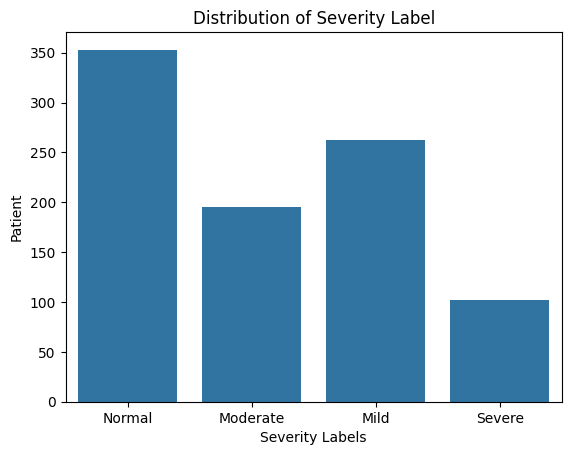

In [11]:
sns.countplot(data=EMG_df, x='Diagnosis Severity')

plt.title('Distribution of Severity Label')
plt.xlabel("Severity Labels")
plt.ylabel("Patient")
plt.show()

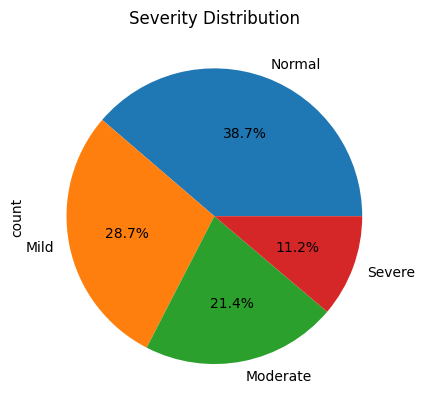

In [12]:
EMG_df['Diagnosis Severity'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Severity Distribution")
plt.show()

## Correlation Analysis

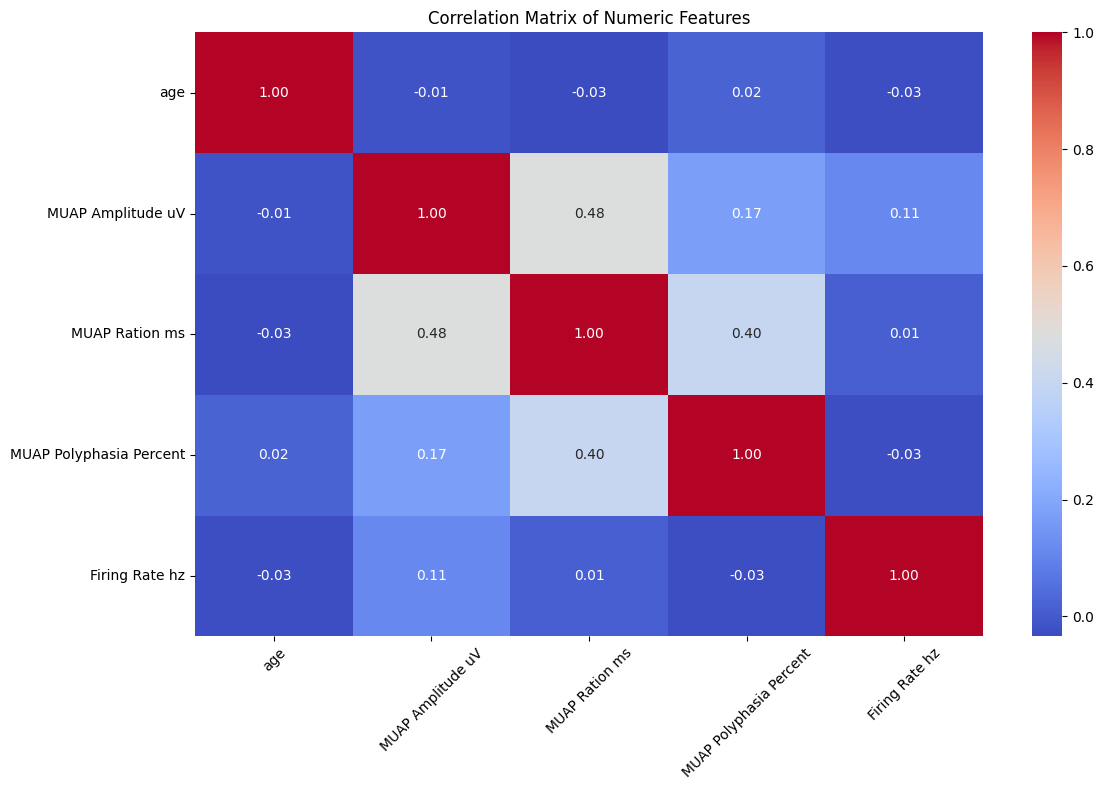

In [13]:
# Correlation matrix to detect collinear features

corr = EMG_df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

## Distribution of Each EMG Feature

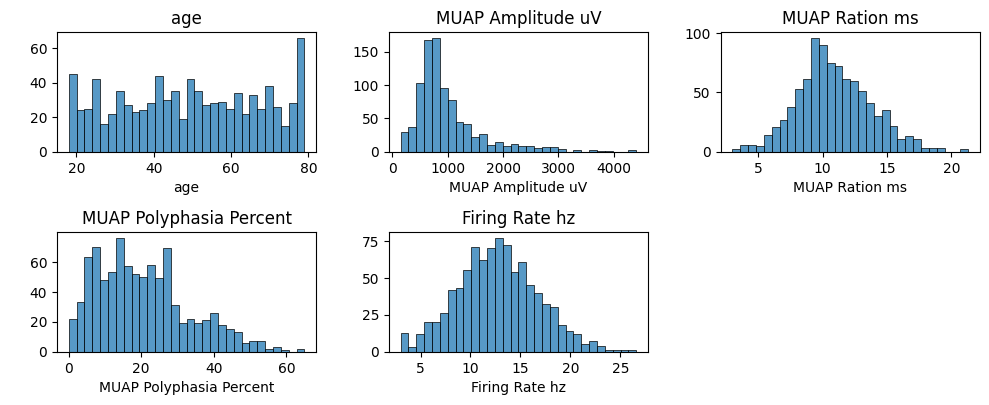

In [14]:
# number of charts per row
cols = 3

# round up the number of rows ; Ensures enough rows to display all features.
rows = math.ceil( len(numeric_features) / cols)

# Create Creates a new figure for all subplots ( witdh,height  )
plt.figure(figsize=(10, rows * 2))


for i, col in enumerate(numeric_features, 1):
    #Creates the i-th subplot in a grid of rows × cols.
    plt.subplot(rows, cols, i)

    # draws histogram + dropna() removes missing values before plottin + splits the data range into 30 buckets +  no density curve
    sns.histplot(EMG_df[col].dropna(), bins=30, kde=False)
    plt.title(f'{col}')
    plt.xlabel(col, fontsize=10)
    plt.ylabel(' ', fontsize=10)

plt.tight_layout()
plt.show()

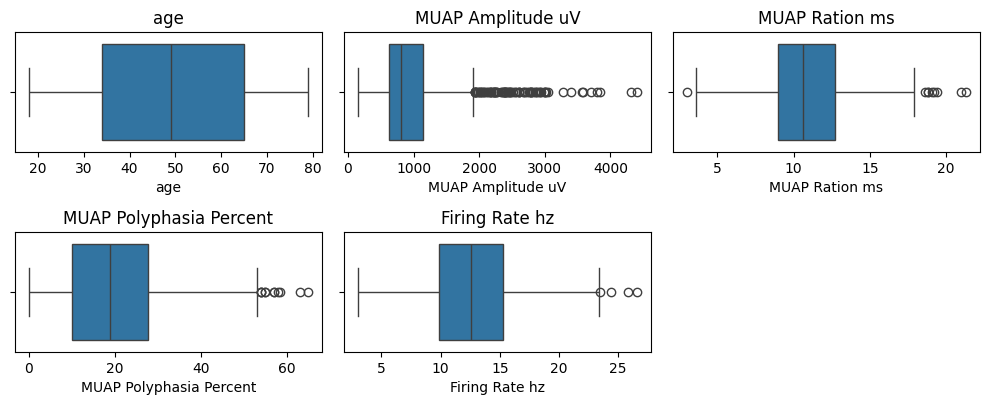

In [15]:
#  Boxplot by Nerve or Severity

plt.figure(figsize=(10, rows * 2))

for i, col in enumerate(numeric_features, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=EMG_df[col].dropna())
    plt.title(f'{col}')
    plt.xlabel(col, fontsize=10)

plt.tight_layout()
plt.show()

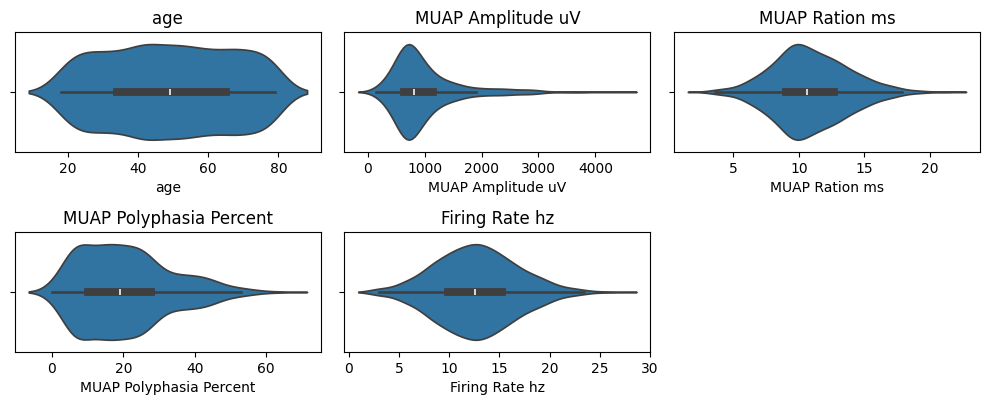

In [16]:
#Violin Plot
plt.figure(figsize=(10, rows * 2))

for i, col in enumerate(numeric_features, 1):
    plt.subplot(rows, cols, i)
    sns.violinplot(x=EMG_df[col].dropna())
    plt.title(f'{col}')
    plt.xlabel(col, fontsize=10)

plt.tight_layout()
plt.show()

### Catagorical Features Distribution

/tmp/ipykernel_26584/1258442633.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=EMG_df, x=col, palette='Set2')
/tmp/ipykernel_26584/1258442633.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=EMG_df, x=col, palette='Set2')
/tmp/ipykernel_26584/1258442633.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=EMG_df, x=col, palette='Set2')
/tmp/ipykernel_26584/1258442633.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` a

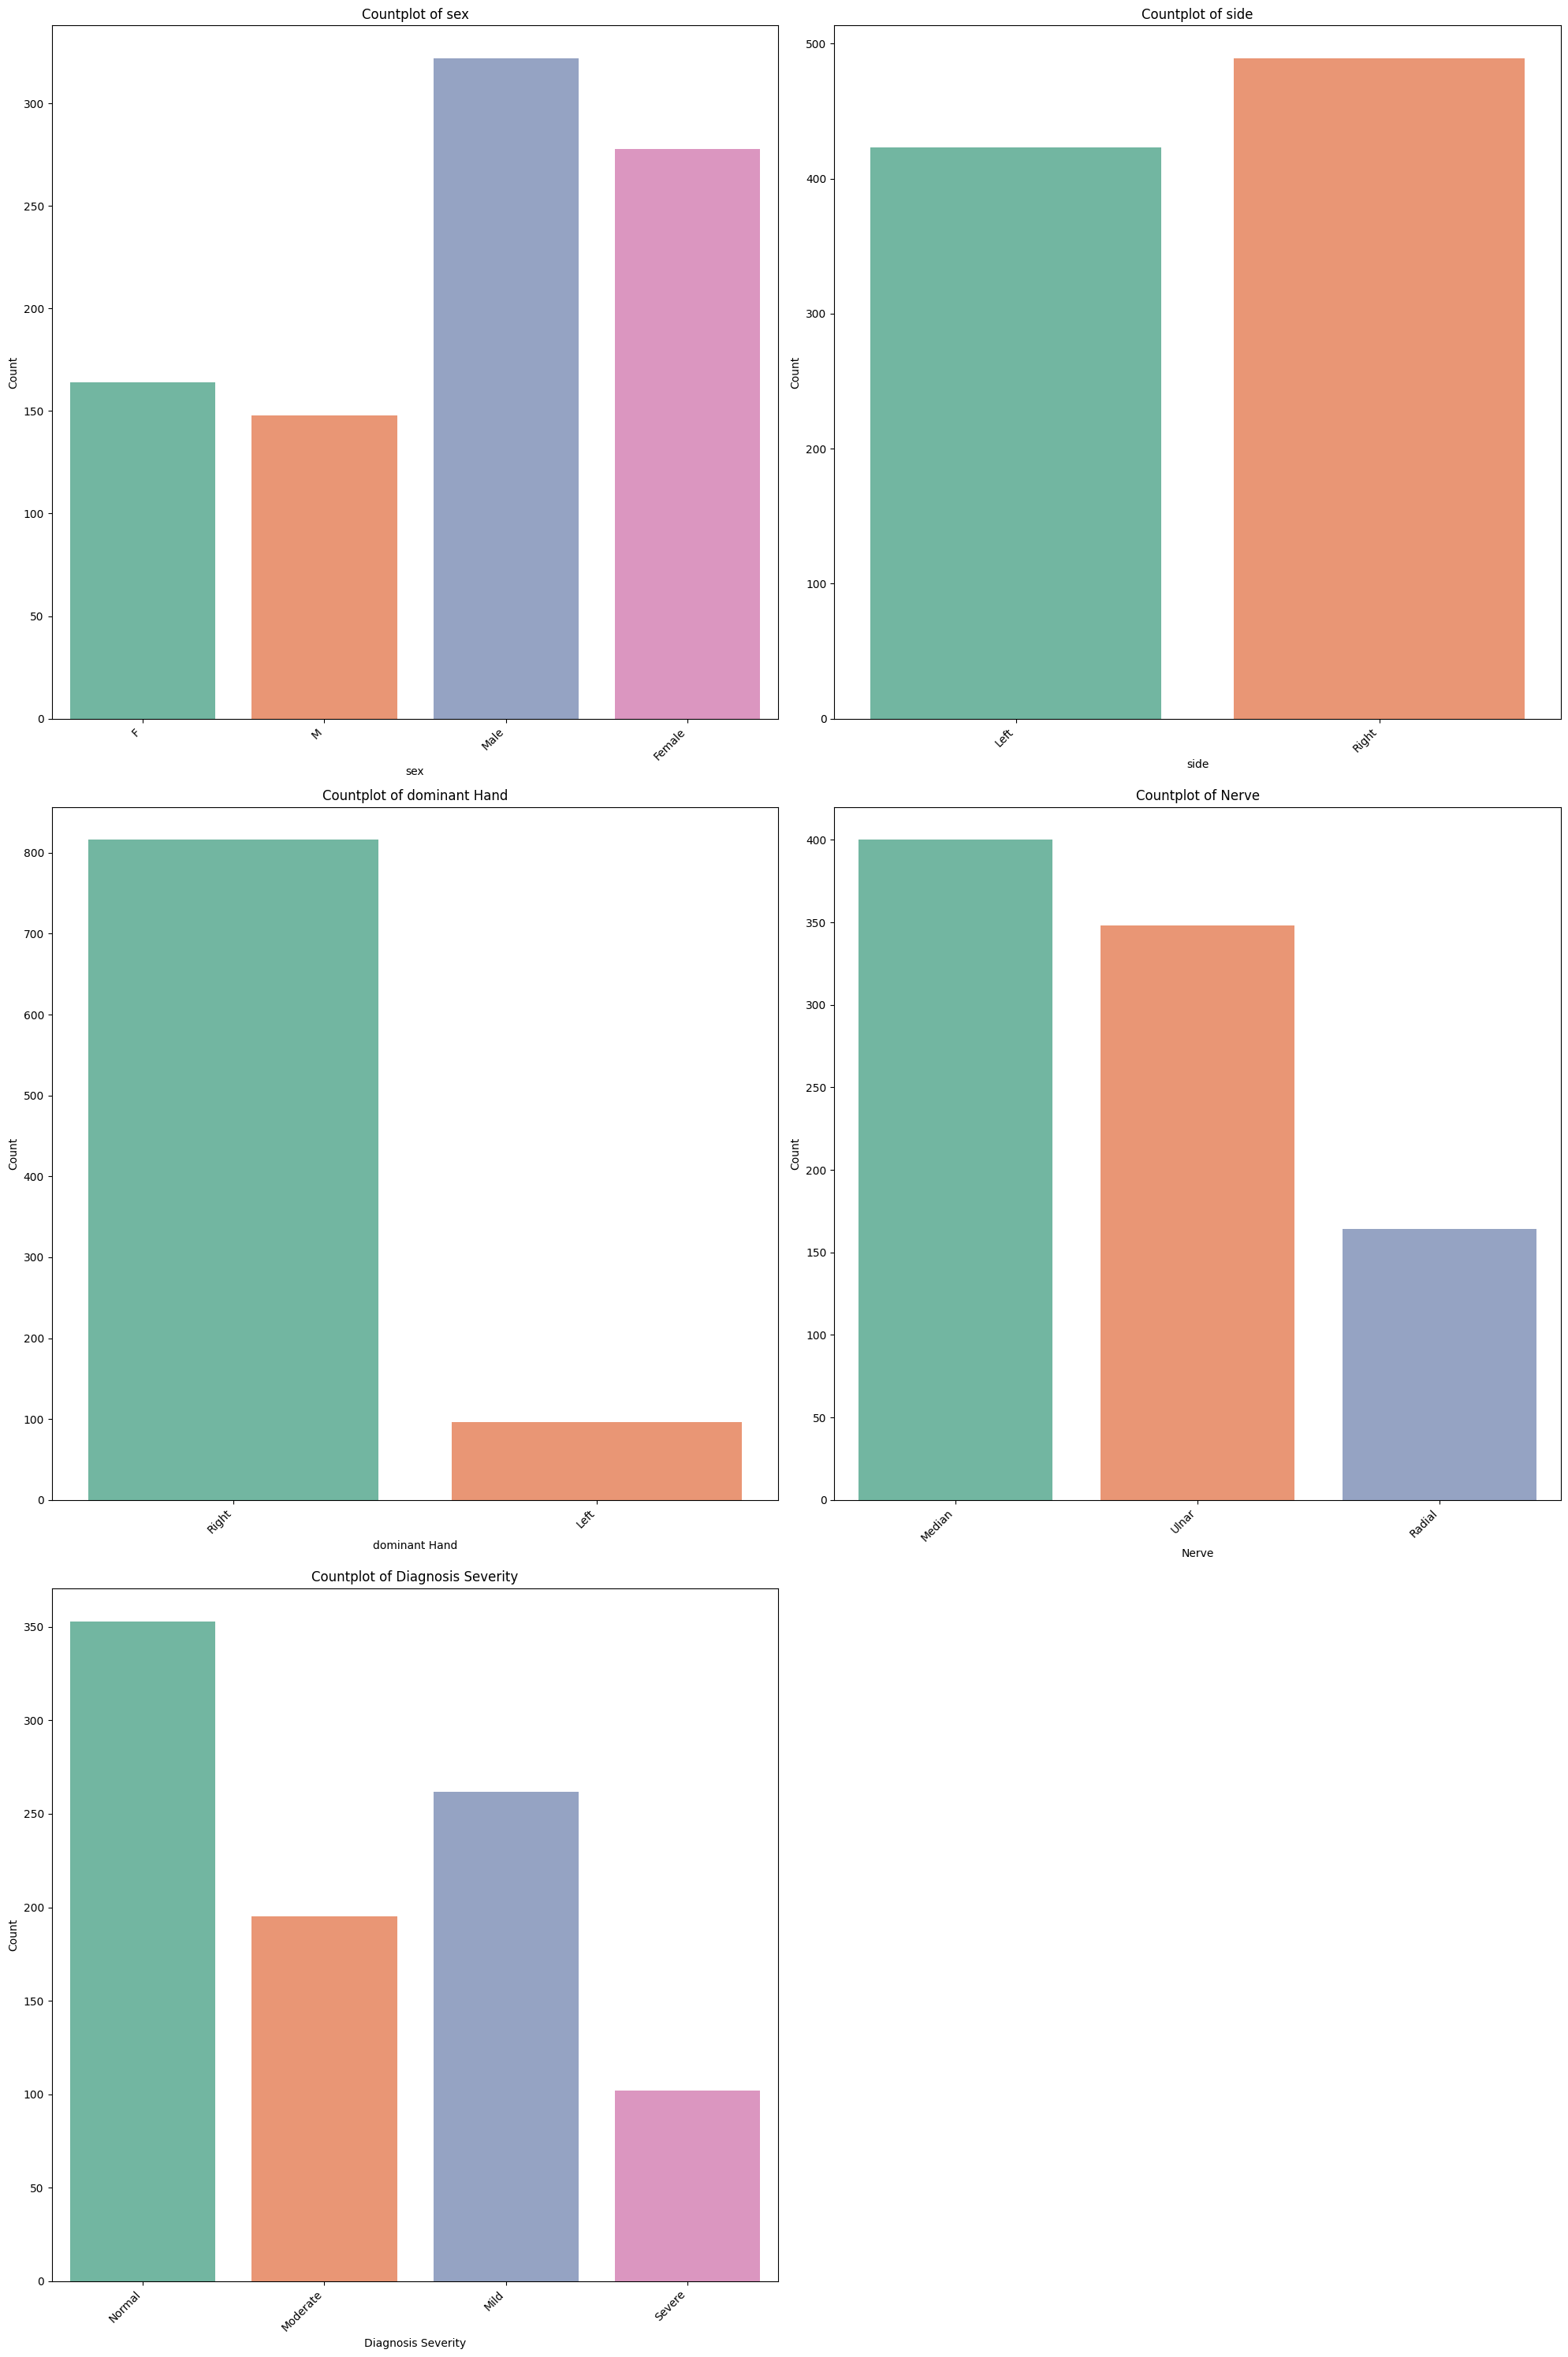

In [17]:
# Count Plot

# Select categorical columns
categorical_cols = EMG_df.select_dtypes(include=['object', 'category']).columns

# Number of categorical features
n_cat = len(categorical_cols)

# Layout
cols = 2   # number of plots per row
rows = math.ceil(n_cat / cols)

# Create figure
plt.figure(figsize=(20, rows * 10))

# Loop for subplots
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(rows, cols, i)
    sns.countplot(data=EMG_df, x=col, palette='Set2')
    plt.title(f'Countplot of {col}', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

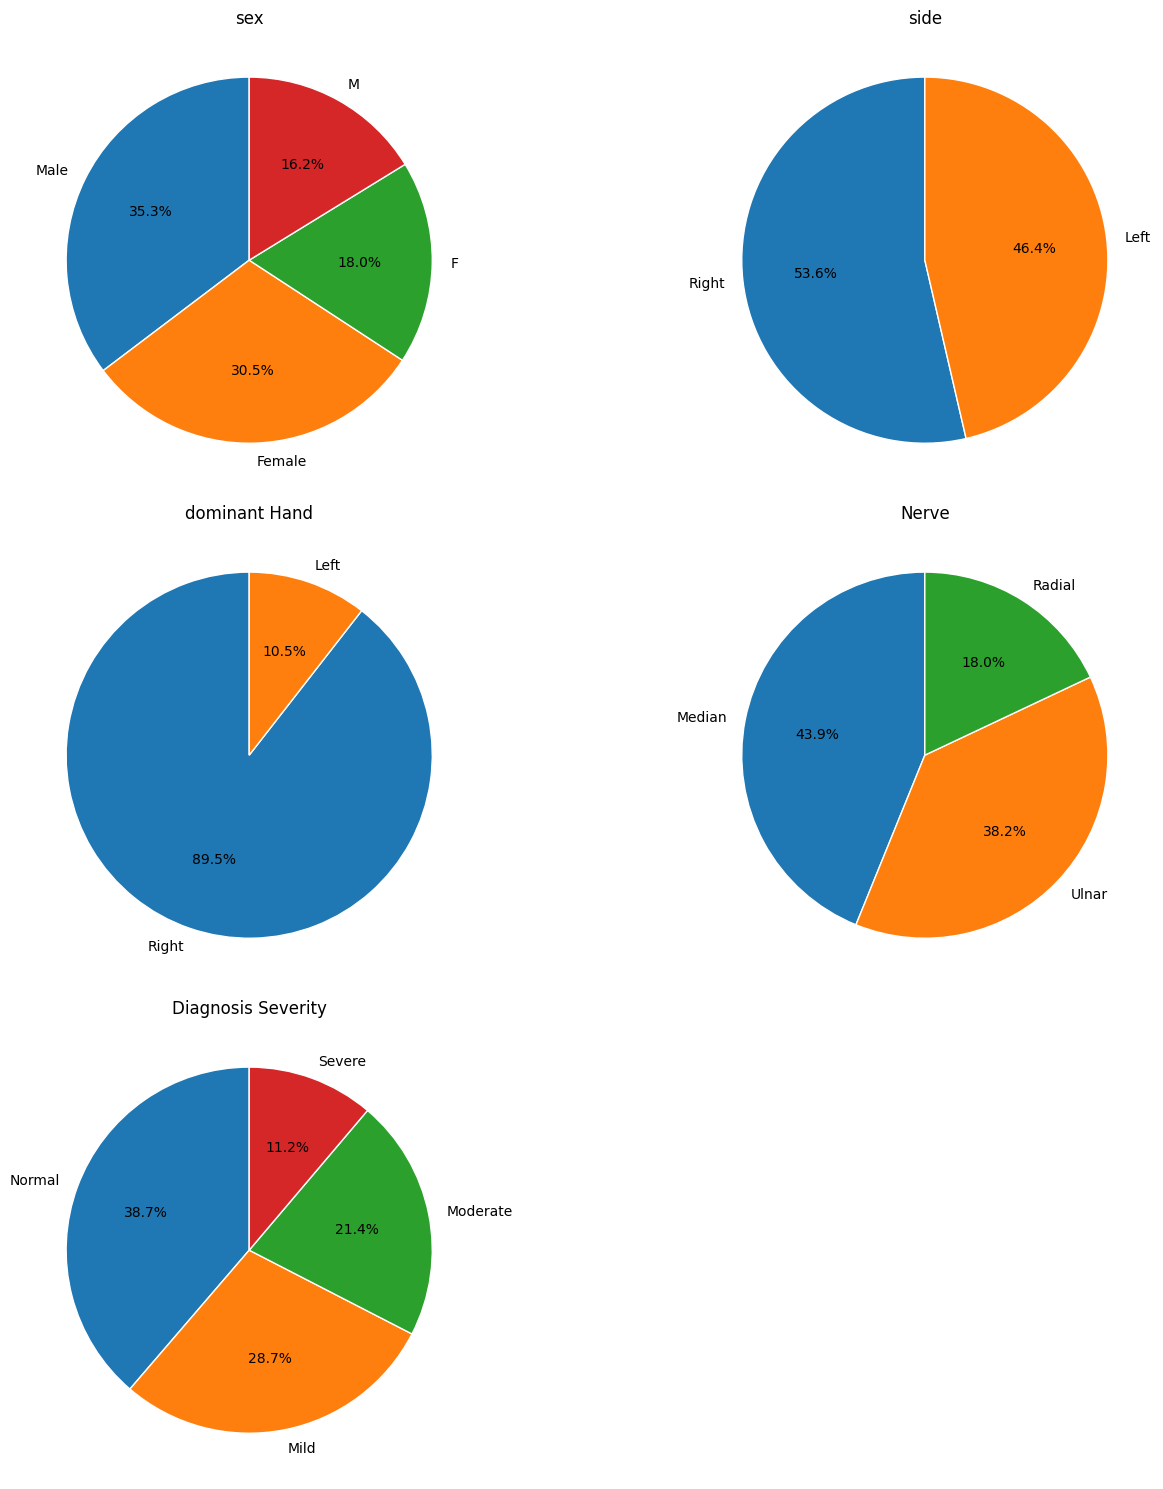

In [18]:
# Pie chart

# Select categorical columns
categorical_cols = EMG_df.select_dtypes(include=['object', 'category']).columns

# Number of categorical features
n_cat = len(categorical_cols)

# Subplot layout
cols = 2
rows = math.ceil(n_cat / cols)

# Create the figure
plt.figure(figsize=(14, rows * 5))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(rows, cols, i)

    # Get counts
    data = EMG_df[col].value_counts()

    # Pie chart
    plt.pie(
        data.values,
        labels=data.index,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 10},
        wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
    )

    plt.title(f'{col}', fontsize=12)

plt.tight_layout()
plt.show()

## Missing Values

In [19]:
print("Missing values per column:\n", EMG_df.isnull().sum()) #Nan None

Missing values per column:
 patient_id                 0
age                        0
sex                        0
side                       0
dominant Hand              0
Nerve                      0
MUAP Amplitude uV          0
MUAP Ration ms             0
MUAP Polyphasia Percent    0
Firing Rate hz             0
Diagnosis Severity         0
dtype: int64


## Duplicates Recoreds


In [20]:
dup_rows = EMG_df.duplicated().sum()
print("\nNumber of Fully Duplicated rows:", dup_rows)


Number of Fully Duplicated rows: 0


## Detecting Messy Format

In [21]:
# Detect Non-Numeric Characters Inside Numeric Columns

for col in EMG_df.select_dtypes(include='object'):
    # Check if column is supposed to be numeric
    try:
        EMG_df[col].astype(float)
        print(f"POSSIBLE WRONG FORMAT → {col}: contains numeric-like strings")
    except:
        pass


In [22]:
# Detect Leading / Trailing Spaces

for col in EMG_df.select_dtypes(include='object'):
    EMG_df[col] = EMG_df[col].astype(str)
    if EMG_df[col].str.contains(r'^\s+|\s+$').any():
        print(f"WARNING: Spaces in {col}")

In [23]:
# Detect Mixed Formats

for col in EMG_df.select_dtypes(include='object'):
    print(f"\nUnique values in {col}:")
    print(EMG_df[col].unique())


Unique values in sex:
['F' 'M' 'Male' 'Female']

Unique values in side:
['Left' 'Right']

Unique values in dominant Hand:
['Right' 'Left']

Unique values in Nerve:
['Median' 'Ulnar' 'Radial']

Unique values in Diagnosis Severity:
['Normal' 'Moderate' 'Mild' 'Severe']


In [24]:
# Detect Unexpected / Invalid Categories

for col in EMG_df.select_dtypes(include='object'):
    print(f"\n{col} → unique values:")
    print(EMG_df[col].value_counts(dropna=False))


sex → unique values:
sex
Male      322
Female    278
F         164
M         148
Name: count, dtype: int64

side → unique values:
side
Right    489
Left     423
Name: count, dtype: int64

dominant Hand → unique values:
dominant Hand
Right    816
Left      96
Name: count, dtype: int64

Nerve → unique values:
Nerve
Median    400
Ulnar     348
Radial    164
Name: count, dtype: int64

Diagnosis Severity → unique values:
Diagnosis Severity
Normal      353
Mild        262
Moderate    195
Severe      102
Name: count, dtype: int64


In [25]:
# Detect Columns with Mixed Types

for col in EMG_df.columns:
    types = EMG_df[col].apply(type).value_counts()
    if len(types) > 1:
        print(f"Mixed types in {col}: {types}")

In [26]:
# Detect Symbols or Patterns in Categorical Columns

import re

for col in EMG_df.select_dtypes(include='object'):
    if EMG_df[col].str.contains(r'\(|\)|\+|\-').any():
        print(f"Possible encoded scale in {col}")

# Preprocessing

##Data Cleaning

In [27]:
EMG_df['sex'] = EMG_df['sex'].replace({
    'M': 'Male',
    'F': 'Female'
})

In [28]:
EMG_df['sex'].value_counts()

,count
sex,
Male,470
Female,442


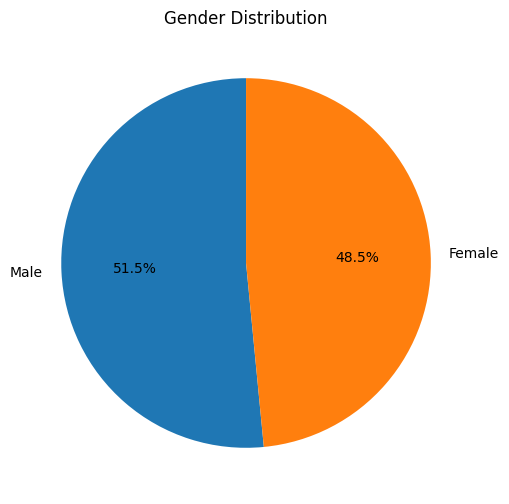

In [29]:
sex_counts = EMG_df['sex'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(sex_counts,
        labels=sex_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Gender Distribution")
plt.show()

In [30]:
EMG_df['dominant Hand'] = EMG_df['dominant Hand'].replace({
    'left': 'Left',
    'right': 'Right'
})

In [31]:
EMG_df = EMG_df.drop(columns=['patient_id'])

##Encoding

In [32]:
EMG_encoded = EMG_df.copy()

###1) Binary Encoding

In [33]:
# Encode binary categorical variables using Mapping


EMG_encoded['sex'] = EMG_encoded['sex'].map({
    'Male': 1,
    'Female': 0
})

EMG_encoded['side'] = EMG_encoded['side'].map({
    'Right': 1,
    'Left': 0
})

EMG_encoded['dominant Hand'] = EMG_encoded['dominant Hand'].map({
    'Right': 1,
    'Left': 0
})

###**2) One-Hot Encoding**

In [34]:
# For Liner Models                -> Nerve_Ulnar, Nerve_Radial

'''
# Apply One-Hot Encoding for the 'Nerve' column
# This converts each nerve type into separate binary columns

EMG_encoded = pd.get_dummies(EMG_encoded, columns=['Nerve'], drop_first=True)

# Type conversation
EMG_encoded[['Nerve_Radial','Nerve_Ulnar']] = EMG_encoded[['Nerve_Radial','Nerve_Ulnar']].astype(int)
'''

"\n# Apply One-Hot Encoding for the 'Nerve' column\n# This converts each nerve type into separate binary columns\n\nEMG_encoded = pd.get_dummies(EMG_encoded, columns=['Nerve'], drop_first=True)\n\n# Type conversation\nEMG_encoded[['Nerve_Radial','Nerve_Ulnar']] = EMG_encoded[['Nerve_Radial','Nerve_Ulnar']].astype(int)\n"

In [35]:
# For Liner Models                -> Nerve_Median, Nerve_Ulnar, Nerve_Radial


# Create one-hot encoded columns for the 'Nerve' feature -> will generate 3 columns: Nerve_Median, Nerve_Ulnar, Nerve_Radial
nerve_dummies = pd.get_dummies(EMG_encoded['Nerve'], prefix='Nerve')

# Convert the dummy variables from boolean/uint to integer (0 and 1)
nerve_dummies = nerve_dummies.astype(int)

# Concatenate the new one-hot encoded columns with the main dataframe
EMG_encoded = pd.concat([EMG_encoded, nerve_dummies], axis=1)

# Drop the original 'Nerve' column since it is now encoded
EMG_encoded.drop('Nerve', axis=1, inplace=True)

###**3) Ordinal Encoding**

In [36]:
# Encode the target variable (Diagnosis Severity)

EMG_encoded['Diagnosis Severity'] = EMG_encoded['Diagnosis Severity'].map({
    'Normal': 0,
    'Mild': 1,
    'Moderate': 2,
    'Severe': 3
})

##Arrange Cols

In [37]:
# Define the target column (the variable we want the model to predict)
target = 'Diagnosis Severity'


# Create a list of columns where the target column is placed at the end
# First take all columns except the target, then add the target column last
cols = [col for col in EMG_encoded.columns if col != target] + [target]


# Reorder the dataframe columns based on the new column list to ensures the target variable appears as the last column
EMG_encoded = EMG_encoded[cols]


# Display the first 5 rows of the dataframe to verify the new column order
EMG_encoded.head()

,age,sex,side,dominant Hand,MUAP Amplitude uV,MUAP Ration ms,MUAP Polyphasia Percent,Firing Rate hz,Nerve_Median,Nerve_Radial,Nerve_Ulnar,Diagnosis Severity
0,69,0,0,1,751.0,10.0,4.7,12.8,1,0,0,0
1,26,0,1,1,2798.0,13.4,23.9,12.2,0,0,1,2
2,47,0,1,1,946.0,9.8,5.8,8.9,0,0,1,0
3,25,1,0,1,1217.0,8.7,14.2,20.1,1,0,0,0
4,41,0,1,1,2763.0,16.3,22.9,17.9,1,0,0,2


##**Train/Test Split**

In [38]:
from sklearn.model_selection import train_test_split

# Separate
X = EMG_encoded.drop(columns=['Diagnosis Severity'])

# target variable
y = EMG_encoded['Diagnosis Severity']


# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,                 # Feature matrix (input variables)
    y,                 # Target variable
    test_size=0.2,     # 20% of the data will be used for testing
    random_state=42,   # Ensures reproducibility (same split every run)
    stratify=y         # Keeps the same class distribution in train and test sets
)

##**Feature Selection**

###1) Statistical Feature Selection

**1) Kruskal-Wallis Test For The Numeric Feature**

In [39]:
from scipy.stats import kruskal
import pandas as pd

# List of numerical features to test their relationship with the target variable
numeric_features = [
    'age',
    'MUAP Amplitude uV',
    'MUAP Ration ms',
    'MUAP Polyphasia Percent',
    'Firing Rate hz'
]

# List to store test results
results = []

# Loop through each numeric feature
for feature in numeric_features:

    # Create a list that will hold the values of the feature for each class of the target
    groups = []

    # For each class in the target variable (Diagnosis Severity)
    for cls in y_train.unique():
        # Select values of the feature corresponding to that class
        groups.append(X_train[y_train == cls][feature])

    # Apply the Kruskal-Wallis test to compare distributions across groups
    stat, p = kruskal(*groups)

    # Store the feature name and its p-value
    results.append({
        'Feature': feature,
        'p-value': p
    })

# Convert results into a DataFrame for easier analysis
results_df = pd.DataFrame(results)

# Mark features as significant if p-value ≤ 0.05
results_df["Significant (p≤0.05)"] = results_df["p-value"].apply(
    lambda x: "Yes" if x <= 0.05 else "No"
)

# Sort features by p-value (most significant first)
results_df = results_df.sort_values("p-value")

# Display the results
results_df

,Feature,p-value,Significant (p≤0.05)
3,MUAP Polyphasia Percent,2.223773e-88,Yes
2,MUAP Ration ms,4.456013e-50,Yes
1,MUAP Amplitude uV,1.568909e-26,Yes
4,Firing Rate hz,2.111645e-01,No
0,age,2.169704e-01,No


**2) Chi-Square Test For The Categorical Features**

In [40]:
from scipy.stats import chi2_contingency
import pandas as pd

# List of categorical features to test their relationship with the target
categorical_features = [
    'sex',
    'side',
    'dominant Hand',
    'Nerve_Median',
    'Nerve_Ulnar',
    'Nerve_Radial'
]

# List to store chi-square test results
chi_results = []

# Loop through each categorical feature
for feature in categorical_features:

    # Create a contingency table between the feature and the target variable
    table = pd.crosstab(X_train[feature], y_train)

    # Perform the Chi-Square test of independence
    chi2, p, dof, expected = chi2_contingency(table)

    # Store the feature name and its p-value
    chi_results.append({
        "Feature": feature,
        "p-value": p
    })

# Convert results into a DataFrame
chi_df = pd.DataFrame(chi_results)

# Sort features by p-value (most significant first)
chi_df = chi_df.sort_values("p-value")

# Mark features as significant if p-value ≤ 0.05
chi_df["Significant (p≤0.05)"] = chi_df["p-value"].apply(
    lambda x: "Yes" if x <= 0.05 else "No"
)

# Display the results
chi_df

,Feature,p-value,Significant (p≤0.05)
1,side,0.020407,Yes
5,Nerve_Radial,0.089099,No
4,Nerve_Ulnar,0.340381,No
2,dominant Hand,0.412273,No
0,sex,0.511668,No
3,Nerve_Median,0.742346,No


###2) Fisher Score

In [41]:
# ANOVA F-test function
from sklearn.feature_selection import f_classif
import pandas as pd


# Apply the ANOVA F-test between each feature in X_train and the target variable y_train
# This test evaluates whether the mean values of a feature differ significantly across target classes
f_scores, p_values = f_classif(
    X_train,
    y_train
    )


# create Df to organize the results
fisher_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Fisher Score': f_scores,
    'p-value': p_values
})


# Sort descending order : Higher Fisher Score indicates stronger relationship with the target variable
fisher_df = fisher_df.sort_values(by='Fisher Score', ascending=False)



fisher_df

,Feature,Fisher Score,p-value
6,MUAP Polyphasia Percent,391.294215,4.420249e-151
5,MUAP Ration ms,123.431891,1.382409e-64
4,MUAP Amplitude uV,63.614080,1.609797e-36
2,side,3.290757,2.022990e-02
9,Nerve_Radial,2.178998,8.918328e-02
0,age,1.461124,2.238847e-01
7,Firing Rate hz,1.325265,2.649770e-01
10,Nerve_Ulnar,1.116555,3.415308e-01
3,dominant Hand,0.954832,4.135851e-01
1,sex,0.766359,5.130919e-01


# ________________________________________________________________________________________________________

#Model Implementation



# Random Forest CV Function

In [42]:
def run_rf_stratified_cv(X, y, experiment_name, model_params=None):

    # Copy features to avoid changing the original data
    X = X.copy()
    X.columns = X.columns.str.replace(' ', '_')

    # Define target mapping
    target_mapping = {
        'Normal': 0,
        'Mild': 1,
        'Moderate': 2,
        'Severe': 3
    }

    # Keep class order fixed
    sorted_classes = sorted(target_mapping.items(), key=lambda x: x[1])
    class_names = [name for name, _ in sorted_classes]
    class_labels = [label for _, label in sorted_classes]

    # Get Severe class info for AP
    severe_label = target_mapping['Severe']
    severe_index = class_labels.index(severe_label)

    # Stratified 5-fold CV
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Store outputs
    metrics_list = []
    fold_reports = []
    confusion_matrices = []

    # Store all predictions across folds
    all_y_true = []
    all_y_pred = []
    all_y_proba = []

    # Default baseline parameters
    default_params = {
        'n_estimators': 100,
        'max_depth': None,
        'min_samples_split': 2,
        'min_samples_leaf': 1,
        'max_features': 'sqrt',
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1
    }

    # Update with tuned parameters if provided
    if model_params is not None:
        default_params.update(model_params)

    print("\n" + "=" * 100)
    print(f"Experiment: {experiment_name}")
    print("=" * 100)

    # Loop through folds
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):

        # Split current fold
        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        # Train model
        model = RandomForestClassifier(**default_params)
        model.fit(X_train_fold, y_train_fold)

        # Predict labels and probabilities
        y_pred = model.predict(X_val_fold)
        y_proba = model.predict_proba(X_val_fold)

        # Save all predictions across folds
        all_y_true.extend(y_val_fold.tolist())
        all_y_pred.extend(y_pred.tolist())
        all_y_proba.append(y_proba)

        # Calculate fold metrics
        acc = accuracy_score(y_val_fold, y_pred)
        precision_macro = precision_score(y_val_fold, y_pred, average='macro', zero_division=0)
        recall_macro = recall_score(y_val_fold, y_pred, average='macro', zero_division=0)
        f1_macro = f1_score(y_val_fold, y_pred, average='macro', zero_division=0)
        mcc = matthews_corrcoef(y_val_fold, y_pred)

        # Calculate AP for Severe class
        y_val_severe = (y_val_fold == severe_label).astype(int)
        y_proba_severe = y_proba[:, severe_index]
        ap_severe = average_precision_score(y_val_severe, y_proba_severe)

        # Save fold metrics
        metrics_list.append({
            'Fold': fold,
            'Accuracy': round(acc, 4),
            'Precision_macro': round(precision_macro, 4),
            'Recall_macro': round(recall_macro, 4),
            'F1_macro': round(f1_macro, 4),
            'MCC': round(mcc, 4),
            'AP_Severe': round(ap_severe, 4)
        })

        # Build classification report for current fold
        report_dict = classification_report(
            y_val_fold,
            y_pred,
            labels=class_labels,
            target_names=class_names,
            output_dict=True,
            zero_division=0
        )

        report_df = pd.DataFrame(report_dict).transpose()
        report_df.insert(0, 'Fold', fold)
        fold_reports.append(report_df)

        # Build confusion matrix for current fold
        cm = confusion_matrix(y_val_fold, y_pred, labels=class_labels)
        confusion_matrices.append(cm)

    # Convert fold metrics to DataFrame
    summary_df = pd.DataFrame(metrics_list)

    print("\nFold-wise Metrics")
    print("-" * 100)
    display(summary_df)

    print("\nClassification Report for Each Fold")
    print("-" * 100)
    for i, report_df in enumerate(fold_reports, start=1):
        print(f"\nFold {i}")
        display(report_df.loc[class_names + ['accuracy', 'macro avg', 'weighted avg']])

    print("\n" + "=" * 100)
    print("Confusion Matrices for Each Fold")
    print("=" * 100)

    # Plot confusion matrix for each fold
    for i, cm in enumerate(confusion_matrices, start=1):
        plt.figure(figsize=(6, 5))
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names
        )
        plt.title(f"{experiment_name} - Fold {i}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()

    # Convert all predictions to arrays
    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)
    all_y_proba = np.vstack(all_y_proba)

    # Aggregated metrics across all folds
    agg_accuracy = accuracy_score(all_y_true, all_y_pred)
    agg_precision = precision_score(all_y_true, all_y_pred, average='macro', zero_division=0)
    agg_recall = recall_score(all_y_true, all_y_pred, average='macro', zero_division=0)
    agg_f1 = f1_score(all_y_true, all_y_pred, average='macro', zero_division=0)
    agg_mcc = matthews_corrcoef(all_y_true, all_y_pred)

    # Aggregated AP for Severe class
    y_true_severe = (all_y_true == severe_label).astype(int)
    y_proba_severe_all = all_y_proba[:, severe_index]
    agg_ap_severe = average_precision_score(y_true_severe, y_proba_severe_all)

    aggregated_metrics_df = pd.DataFrame([{
        'Accuracy': round(agg_accuracy, 4),
        'Precision_macro': round(agg_precision, 4),
        'Recall_macro': round(agg_recall, 4),
        'F1_macro': round(agg_f1, 4),
        'MCC': round(agg_mcc, 4),
        'AP_Severe': round(agg_ap_severe, 4)
    }])

    print("\nAggregated Metrics Across All Folds")
    print("-" * 100)
    display(aggregated_metrics_df)

    # Aggregated classification report across all folds
    aggregated_report_dict = classification_report(
        all_y_true,
        all_y_pred,
        labels=class_labels,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    aggregated_report_df = pd.DataFrame(aggregated_report_dict).transpose().round(4)

    print("\nAggregated Classification Report Across All Folds")
    print("-" * 100)
    display(aggregated_report_df.loc[class_names + ['accuracy', 'macro avg', 'weighted avg']])

    # Aggregated confusion matrix
    total_cm = np.sum(confusion_matrices, axis=0)

    print("\n" + "=" * 100)
    print("Aggregated Confusion Matrix")
    print("=" * 100)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        total_cm,
        annot=True,
        fmt='d',
        cmap='Greens',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"{experiment_name} - Aggregated Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # Combine all fold reports
    all_reports_df = pd.concat(fold_reports, axis=0)

    return summary_df, all_reports_df, aggregated_metrics_df, aggregated_report_df, total_cm

# Baseline Random Forest (All Features)


Experiment: Random Forest Baseline - All Features

Fold-wise Metrics
----------------------------------------------------------------------------------------------------


,Fold,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,1,0.6849,0.7012,0.6961,0.6913,0.5567,0.8198
1,2,0.6781,0.6788,0.6753,0.6699,0.5461,0.8836
2,3,0.7260,0.7271,0.6597,0.6679,0.6167,0.8523
3,4,0.6712,0.6787,0.6636,0.6697,0.5354,0.6760
4,5,0.6138,0.6059,0.6035,0.6040,0.4530,0.7921



Classification Report for Each Fold
----------------------------------------------------------------------------------------------------

Fold 1


,Fold,precision,recall,f1-score,support
Normal,1,0.671429,0.839286,0.746032,56.000000
Mild,1,0.625000,0.476190,0.540541,42.000000
Moderate,1,0.730769,0.593750,0.655172,32.000000
Severe,1,0.777778,0.875000,0.823529,16.000000
accuracy,1,0.684932,0.684932,0.684932,0.684932
macro avg,1,0.701244,0.696057,0.691319,146.000000
weighted avg,1,0.682733,0.684932,0.675496,146.000000



Fold 2


...


Fold 4


,Fold,precision,recall,f1-score,support
Normal,4,0.688525,0.750000,0.717949,56.000000
Mild,4,0.605263,0.547619,0.575000,42.000000
Moderate,4,0.687500,0.709677,0.698413,31.000000
Severe,4,0.733333,0.647059,0.687500,17.000000
accuracy,4,0.671233,0.671233,0.671233,0.671233
macro avg,4,0.678655,0.663589,0.669715,146.000000
weighted avg,4,0.669573,0.671233,0.669133,146.000000



Fold 5


,Fold,precision,recall,f1-score,support
Normal,5,0.672131,0.732143,0.700855,56.000000
Mild,5,0.526316,0.476190,0.500000,42.000000
Moderate,5,0.600000,0.580645,0.590164,31.000000
Severe,5,0.625000,0.625000,0.625000,16.000000
accuracy,5,0.613793,0.613793,0.613793,0.613793
macro avg,5,0.605862,0.603495,0.604005,145.000000
weighted avg,5,0.609273,0.613793,0.610641,145.000000



Confusion Matrices for Each Fold


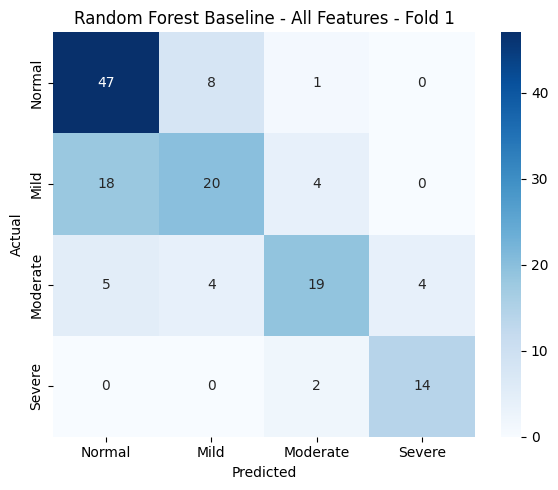

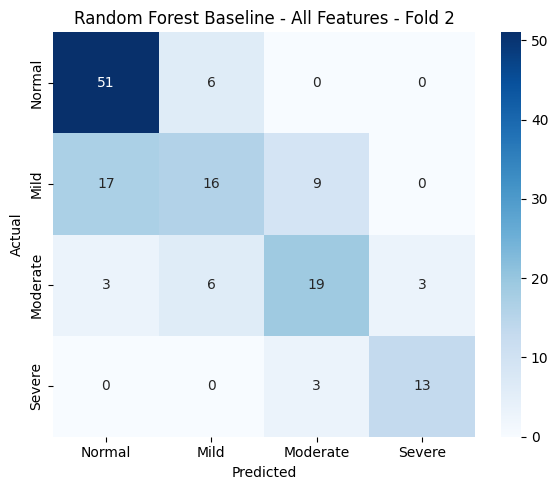

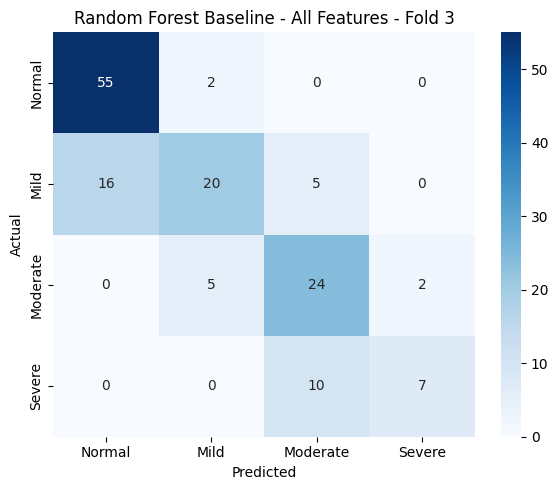

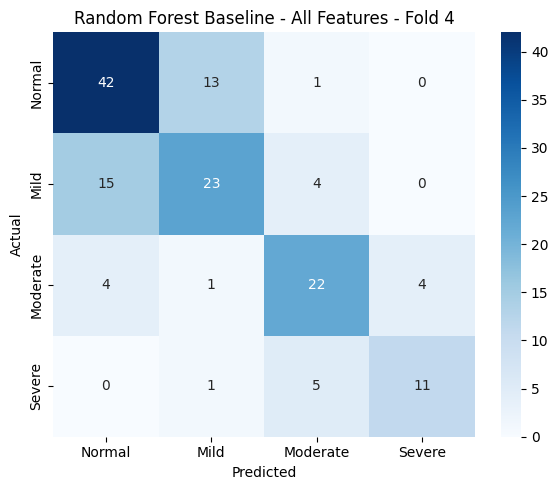

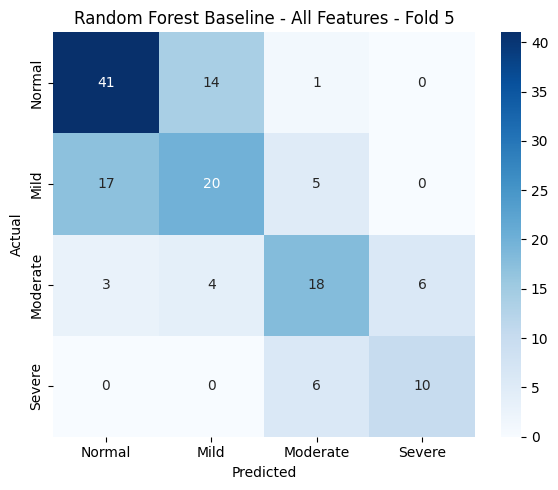


Aggregated Metrics Across All Folds
----------------------------------------------------------------------------------------------------


,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,0.6749,0.6757,0.6588,0.6633,0.5398,0.7848



Aggregated Classification Report Across All Folds
----------------------------------------------------------------------------------------------------


,precision,recall,f1-score,support
Normal,0.7066,0.8369,0.7662,282.0000
Mild,0.6074,0.4737,0.5323,209.0000
Moderate,0.6456,0.6538,0.6497,156.0000
Severe,0.7432,0.6707,0.7051,82.0000
accuracy,0.6749,0.6749,0.6749,0.6749
macro avg,0.6757,0.6588,0.6633,729.0000
weighted avg,0.6692,0.6749,0.6673,729.0000



Aggregated Confusion Matrix


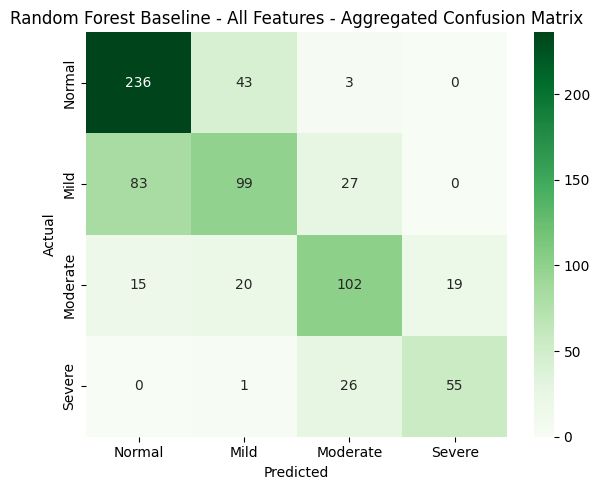

In [43]:
all_features_results, all_feature_reports, all_feature_agg_metrics, all_feature_agg_report, all_feature_cm = run_rf_stratified_cv(
    X=X_train,
    y=y_train,
    experiment_name='Random Forest Baseline - All Features'
)

# Baseline Random Forest  (Selected Features)


Experiment: Random Forest Baseline - Selected Features

Fold-wise Metrics
----------------------------------------------------------------------------------------------------


,Fold,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,1,0.6438,0.6613,0.6488,0.6525,0.4958,0.7932
1,2,0.6575,0.6526,0.6328,0.6383,0.5115,0.8838
2,3,0.7055,0.7066,0.6935,0.6977,0.5833,0.7930
3,4,0.6301,0.6264,0.6158,0.6202,0.4764,0.7413
4,5,0.6000,0.5857,0.5783,0.5805,0.4324,0.7540



Classification Report for Each Fold
----------------------------------------------------------------------------------------------------

Fold 1


,Fold,precision,recall,f1-score,support
Normal,1,0.661538,0.767857,0.710744,56.000000
Mild,1,0.558824,0.452381,0.500000,42.000000
Moderate,1,0.625000,0.625000,0.625000,32.000000
Severe,1,0.800000,0.750000,0.774194,16.000000
accuracy,1,0.643836,0.643836,0.643836,0.643836
macro avg,1,0.661340,0.648810,0.652484,146.000000
weighted avg,1,0.639156,0.643836,0.638279,146.000000



Fold 2


...


Fold 4


,Fold,precision,recall,f1-score,support
Normal,4,0.693548,0.767857,0.728814,56.000000
Mild,4,0.538462,0.500000,0.518519,42.000000
Moderate,4,0.586207,0.548387,0.566667,31.000000
Severe,4,0.687500,0.647059,0.666667,17.000000
accuracy,4,0.630137,0.630137,0.630137,0.630137
macro avg,4,0.626429,0.615826,0.620166,146.000000
weighted avg,4,0.625438,0.630137,0.626653,146.000000



Fold 5


,Fold,precision,recall,f1-score,support
Normal,5,0.666667,0.750000,0.705882,56.0
Mild,5,0.527778,0.452381,0.487179,42.0
Moderate,5,0.548387,0.548387,0.548387,31.0
Severe,5,0.600000,0.562500,0.580645,16.0
accuracy,5,0.600000,0.600000,0.600000,0.6
macro avg,5,0.585708,0.578317,0.580524,145.0
weighted avg,5,0.593793,0.600000,0.595043,145.0



Confusion Matrices for Each Fold


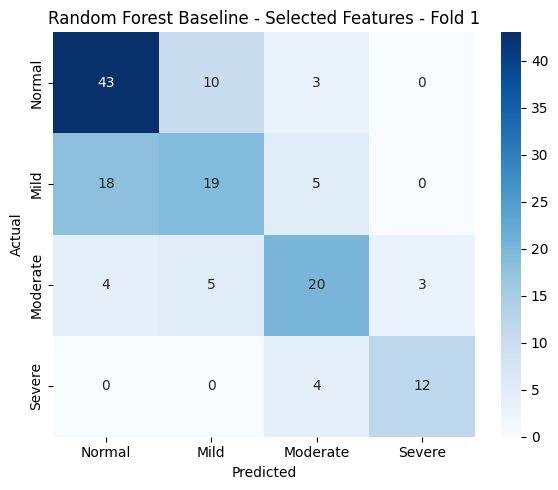

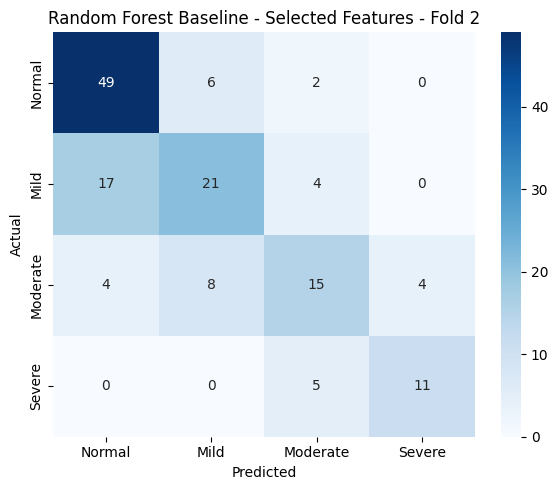

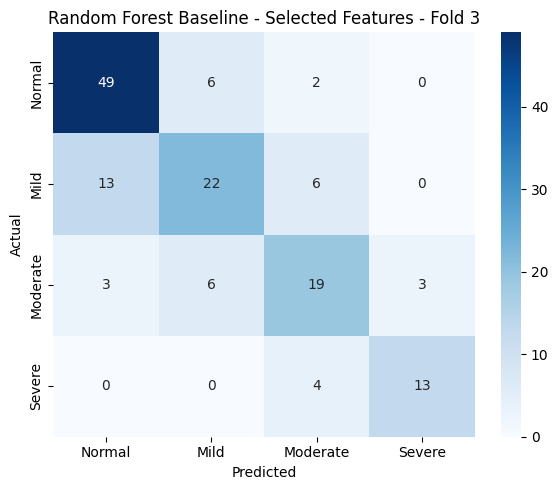

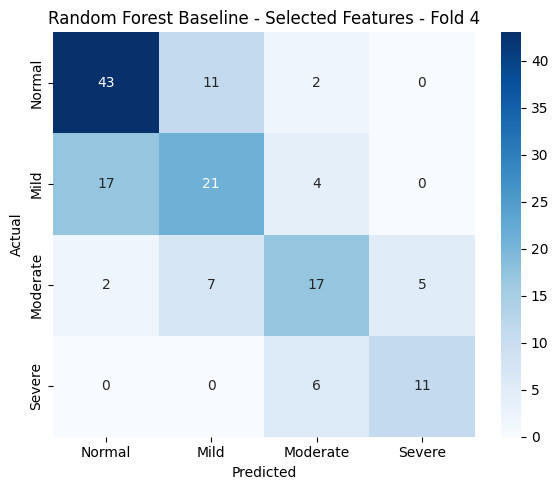

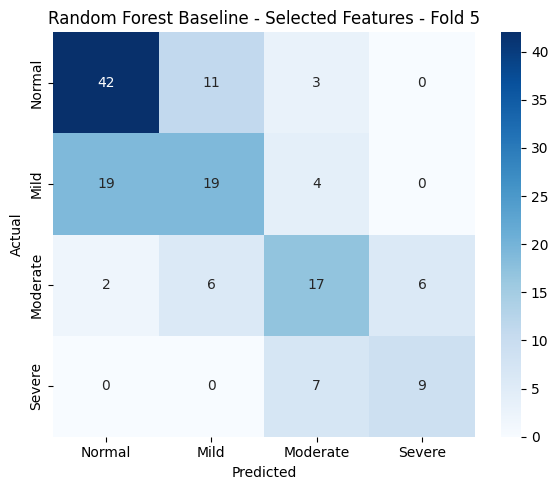


Aggregated Metrics Across All Folds
----------------------------------------------------------------------------------------------------


,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,0.6475,0.6466,0.6341,0.6383,0.4997,0.7939



Aggregated Classification Report Across All Folds
----------------------------------------------------------------------------------------------------


,precision,recall,f1-score,support
Normal,0.6954,0.8014,0.7446,282.0000
Mild,0.5730,0.4880,0.5271,209.0000
Moderate,0.5906,0.5641,0.5770,156.0000
Severe,0.7273,0.6829,0.7044,82.0000
accuracy,0.6475,0.6475,0.6475,0.6475
macro avg,0.6466,0.6341,0.6383,729.0000
weighted avg,0.6415,0.6475,0.6419,729.0000



Aggregated Confusion Matrix


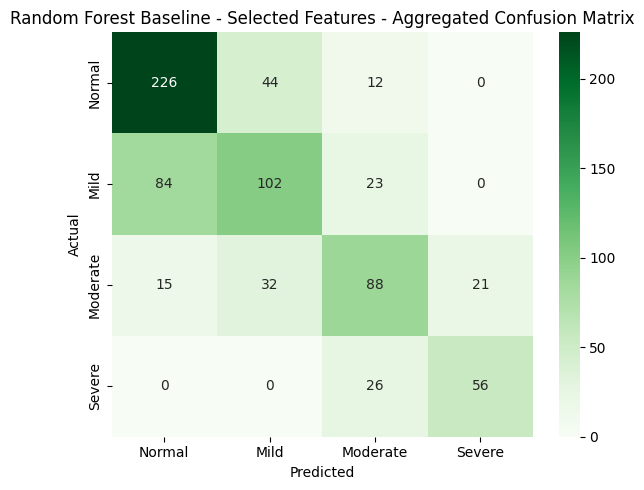

In [44]:
selected_features = [
    'MUAP Amplitude uV',
    'MUAP Ration ms',
    'MUAP Polyphasia Percent'
]

X_train_selected = X_train[selected_features].copy()
X_test_selected = X_test[selected_features].copy()

selected_features_results, selected_feature_reports, selected_feature_agg_metrics, selected_feature_agg_report, selected_feature_cm = run_rf_stratified_cv(
    X=X_train_selected,
    y=y_train,
    experiment_name='Random Forest Baseline - Selected Features'
)

# Comparison

In [45]:
baseline_comparison = pd.DataFrame({
    'All Features': all_features_results.drop(columns='Fold').mean(),
    'Selected Features': selected_features_results.drop(columns='Fold').mean()
})

print("Random Forest Baseline Comparison")
display(baseline_comparison)


Random Forest Baseline Comparison


,All Features,Selected Features
Accuracy,0.67480,0.64738
Precision_macro,0.67834,0.64652
Recall_macro,0.65964,0.63384
F1_macro,0.66056,0.63784
MCC,0.54158,0.49988
AP_Severe,0.80476,0.79306


In [46]:

print("All Features - Aggregated Classification Report")
display(all_feature_agg_report.loc[['Normal', 'Mild', 'Moderate', 'Severe', 'accuracy', 'macro avg', 'weighted avg']])
print('-' * 100)
print("\nSelected Features - Aggregated Classification Report")
display(selected_feature_agg_report.loc[['Normal', 'Mild', 'Moderate', 'Severe', 'accuracy', 'macro avg', 'weighted avg']])

All Features - Aggregated Classification Report


,precision,recall,f1-score,support
Normal,0.7066,0.8369,0.7662,282.0000
Mild,0.6074,0.4737,0.5323,209.0000
Moderate,0.6456,0.6538,0.6497,156.0000
Severe,0.7432,0.6707,0.7051,82.0000
accuracy,0.6749,0.6749,0.6749,0.6749
macro avg,0.6757,0.6588,0.6633,729.0000
weighted avg,0.6692,0.6749,0.6673,729.0000


----------------------------------------------------------------------------------------------------

Selected Features - Aggregated Classification Report


,precision,recall,f1-score,support
Normal,0.6954,0.8014,0.7446,282.0000
Mild,0.5730,0.4880,0.5271,209.0000
Moderate,0.5906,0.5641,0.5770,156.0000
Severe,0.7273,0.6829,0.7044,82.0000
accuracy,0.6475,0.6475,0.6475,0.6475
macro avg,0.6466,0.6341,0.6383,729.0000
weighted avg,0.6415,0.6475,0.6419,729.0000


# Hyperparameter Tuning

In [47]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample']
}

all_param_combinations = list(product(
    param_grid['n_estimators'],
    param_grid['max_depth'],
    param_grid['min_samples_split'],
    param_grid['min_samples_leaf'],
    param_grid['max_features'],
    param_grid['class_weight']
))

print(f"Total combinations: {len(all_param_combinations)}")

Total combinations: 432


In [48]:
all_combo_results = []

for combo_id, (
    n_estimators,
    max_depth,
    min_samples_split,
    min_samples_leaf,
    max_features,
    class_weight
) in enumerate(all_param_combinations, start=1):

    model_params = {
        'n_estimators': n_estimators,
        'max_depth': max_depth,
        'min_samples_split': min_samples_split,
        'min_samples_leaf': min_samples_leaf,
        'max_features': max_features,
        'class_weight': class_weight
    }

    X_used = X_train_selected.copy()
    X_used.columns = X_used.columns.str.replace(' ', '_')
    y_used = y_train.copy()

    target_mapping = {
        'Normal': 0,
        'Mild': 1,
        'Moderate': 2,
        'Severe': 3
    }

    class_labels = [0, 1, 2, 3]
    severe_label = target_mapping['Severe']
    severe_index = class_labels.index(severe_label)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    combo_fold_results = []
    all_y_true = []
    all_y_pred = []
    all_y_proba = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_used, y_used), start=1):

        X_train_fold = X_used.iloc[train_idx]
        X_val_fold = X_used.iloc[val_idx]
        y_train_fold = y_used.iloc[train_idx]
        y_val_fold = y_used.iloc[val_idx]

        model = RandomForestClassifier(
            random_state=42,
            n_jobs=-1,
            **model_params
        )

        model.fit(X_train_fold, y_train_fold)

        y_pred = model.predict(X_val_fold)
        y_proba = model.predict_proba(X_val_fold)

        all_y_true.extend(y_val_fold.tolist())
        all_y_pred.extend(y_pred.tolist())
        all_y_proba.append(y_proba)

        acc = accuracy_score(y_val_fold, y_pred)
        precision_macro = precision_score(y_val_fold, y_pred, average='macro', zero_division=0)
        recall_macro = recall_score(y_val_fold, y_pred, average='macro', zero_division=0)
        f1_macro = f1_score(y_val_fold, y_pred, average='macro', zero_division=0)
        mcc = matthews_corrcoef(y_val_fold, y_pred)

        y_val_severe = (y_val_fold == severe_label).astype(int)
        y_proba_severe = y_proba[:, severe_index]
        ap_severe = average_precision_score(y_val_severe, y_proba_severe)

        combo_fold_results.append({
            'Fold': fold,
            'Accuracy': round(acc, 4),
            'Precision_macro': round(precision_macro, 4),
            'Recall_macro': round(recall_macro, 4),
            'F1_macro': round(f1_macro, 4),
            'MCC': round(mcc, 4),
            'AP_Severe': round(ap_severe, 4)
        })

    combo_fold_df = pd.DataFrame(combo_fold_results)

    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)
    all_y_proba = np.vstack(all_y_proba)

    agg_accuracy = accuracy_score(all_y_true, all_y_pred)
    agg_precision = precision_score(all_y_true, all_y_pred, average='macro', zero_division=0)
    agg_recall = recall_score(all_y_true, all_y_pred, average='macro', zero_division=0)
    agg_f1 = f1_score(all_y_true, all_y_pred, average='macro', zero_division=0)
    agg_mcc = matthews_corrcoef(all_y_true, all_y_pred)

    y_true_severe = (all_y_true == severe_label).astype(int)
    y_proba_severe_all = all_y_proba[:, severe_index]
    agg_ap_severe = average_precision_score(y_true_severe, y_proba_severe_all)

    print(f"\n{'=' * 120}")
    print(f"Combination {combo_id}/{len(all_param_combinations)}")
    print(
        f"n_estimators={n_estimators}, max_depth={max_depth}, "
        f"min_samples_split={min_samples_split}, min_samples_leaf={min_samples_leaf}, "
        f"max_features={max_features}, class_weight={class_weight}"
    )

    print("\nFold-wise Results:")
    display(combo_fold_df)

    combo_summary = {
        'Combo_ID': combo_id,
        'n_estimators': n_estimators,
        'max_depth': max_depth,
        'min_samples_split': min_samples_split,
        'min_samples_leaf': min_samples_leaf,
        'max_features': max_features,
        'class_weight': class_weight,

        'Accuracy_Mean': round(combo_fold_df['Accuracy'].mean(), 4),
        'Precision_Mean': round(combo_fold_df['Precision_macro'].mean(), 4),
        'Recall_Mean': round(combo_fold_df['Recall_macro'].mean(), 4),
        'F1_Mean': round(combo_fold_df['F1_macro'].mean(), 4),
        'MCC_Mean': round(combo_fold_df['MCC'].mean(), 4),
        'AP_Severe_Mean': round(combo_fold_df['AP_Severe'].mean(), 4),

        'Accuracy_Agg': round(agg_accuracy, 4),
        'Precision_Agg': round(agg_precision, 4),
        'Recall_Agg': round(agg_recall, 4),
        'F1_Agg': round(agg_f1, 4),
        'MCC_Agg': round(agg_mcc, 4),
        'AP_Severe_Agg': round(agg_ap_severe, 4)
    }

    all_combo_results.append(combo_summary)

    print(
        f"[{combo_id:03}] "
        f"Accuracy_Mean={combo_summary['Accuracy_Mean']:.4f} | "
        f"Precision_Mean={combo_summary['Precision_Mean']:.4f} | "
        f"Recall_Mean={combo_summary['Recall_Mean']:.4f} | "
        f"F1_Mean={combo_summary['F1_Mean']:.4f} | "
        f"MCC_Mean={combo_summary['MCC_Mean']:.4f} | "
        f"AP_Severe_Mean={combo_summary['AP_Severe_Mean']:.4f}"
    )

    print(
        f"Aggregated -> "
        f"Accuracy={combo_summary['Accuracy_Agg']:.4f} | "
        f"Precision={combo_summary['Precision_Agg']:.4f} | "
        f"Recall={combo_summary['Recall_Agg']:.4f} | "
        f"F1={combo_summary['F1_Agg']:.4f} | "
        f"MCC={combo_summary['MCC_Agg']:.4f} | "
        f"AP_Severe={combo_summary['AP_Severe_Agg']:.4f}"
    )


Combination 1/432
n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=1, max_features=sqrt, class_weight=balanced

Fold-wise Results:


,Fold,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,1,0.6438,0.6613,0.6488,0.6525,0.4958,0.7932
1,2,0.6575,0.6526,0.6328,0.6383,0.5115,0.8838
2,3,0.7055,0.7066,0.6935,0.6977,0.5833,0.7930
3,4,0.6301,0.6264,0.6158,0.6202,0.4764,0.7413
4,5,0.6000,0.5857,0.5783,0.5805,0.4324,0.7540


[001] Accuracy_Mean=0.6474 | Precision_Mean=0.6465 | Recall_Mean=0.6338 | F1_Mean=0.6378 | MCC_Mean=0.4999 | AP_Severe_Mean=0.7931
Aggregated -> Accuracy=0.6475 | Precision=0.6466 | Recall=0.6341 | F1=0.6383 | MCC=0.4997 | AP_Severe=0.7939

Combination 2/432
n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=1, max_features=sqrt, class_weight=balanced_subsample

Fold-wise Results:


,Fold,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,1,0.6164,0.6073,0.6060,0.6062,0.4575,0.7661
1,2,0.6370,0.6309,0.6165,0.6200,0.4825,0.8710
2,3,0.6712,0.6723,0.6580,0.6614,0.5354,0.7517
3,4,0.6096,0.6079,0.5995,0.6027,0.4477,0.7186
4,5,0.5931,0.5889,0.5739,0.5796,0.4215,0.7410


[002] Accuracy_Mean=0.6255 | Precision_Mean=0.6215 | Recall_Mean=0.6108 | F1_Mean=0.6140 | MCC_Mean=0.4689 | AP_Severe_Mean=0.7697
Aggregated -> Accuracy=0.6255 | Precision=0.6215 | Recall=0.6109 | F1=0.6146 | MCC=0.4686 | AP_Severe=0.7737

Combination 3/432
n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=1, max_features=log2, class_weight=balanced

Fold-wise Results:


...

[430] Accuracy_Mean=0.6611 | Precision_Mean=0.6533 | Recall_Mean=0.6728 | F1_Mean=0.6587 | MCC_Mean=0.5256 | AP_Severe_Mean=0.8347
Aggregated -> Accuracy=0.6612 | Precision=0.6520 | Recall=0.6723 | F1=0.6596 | MCC=0.5250 | AP_Severe=0.8232

Combination 431/432
n_estimators=300, max_depth=20, min_samples_split=10, min_samples_leaf=4, max_features=log2, class_weight=balanced

Fold-wise Results:


,Fold,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,1,0.6507,0.6387,0.6815,0.6543,0.5136,0.8164
1,2,0.6507,0.6312,0.6593,0.6411,0.5112,0.9115
2,3,0.6986,0.6990,0.6969,0.6928,0.5776,0.8126
3,4,0.6712,0.6618,0.6748,0.6676,0.5396,0.7606
4,5,0.6414,0.6411,0.6660,0.6495,0.4962,0.8276


[431] Accuracy_Mean=0.6625 | Precision_Mean=0.6544 | Recall_Mean=0.6757 | F1_Mean=0.6611 | MCC_Mean=0.5276 | AP_Severe_Mean=0.8257
Aggregated -> Accuracy=0.6626 | Precision=0.6533 | Recall=0.6753 | F1=0.6617 | MCC=0.5271 | AP_Severe=0.8189

Combination 432/432
n_estimators=300, max_depth=20, min_samples_split=10, min_samples_leaf=4, max_features=log2, class_weight=balanced_subsample

Fold-wise Results:


,Fold,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,1,0.6644,0.6527,0.6920,0.6658,0.5320,0.8466
1,2,0.6575,0.6365,0.6637,0.6452,0.5209,0.9122
2,3,0.6849,0.6860,0.6779,0.6766,0.5579,0.8219
3,4,0.6575,0.6500,0.6643,0.6564,0.5208,0.7595
4,5,0.6414,0.6411,0.6660,0.6495,0.4962,0.8332


[432] Accuracy_Mean=0.6611 | Precision_Mean=0.6533 | Recall_Mean=0.6728 | F1_Mean=0.6587 | MCC_Mean=0.5256 | AP_Severe_Mean=0.8347
Aggregated -> Accuracy=0.6612 | Precision=0.6520 | Recall=0.6723 | F1=0.6596 | MCC=0.5250 | AP_Severe=0.8232


# Rank Results + Best Combination

In [49]:
all_combo_results_df = pd.DataFrame(all_combo_results)

ranked_results_df = all_combo_results_df.sort_values(
    by='F1_Mean',
    ascending=False
).reset_index(drop=True)

ranked_results_df

,Combo_ID,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,class_weight,Accuracy_Mean,Precision_Mean,Recall_Mean,F1_Mean,MCC_Mean,AP_Severe_Mean,Accuracy_Agg,Precision_Agg,Recall_Agg,F1_Agg,MCC_Agg,AP_Severe_Agg
0,387,300,15.0,10,1,log2,balanced,0.6708,0.6676,0.6864,0.6738,0.5381,0.8131,0.6708,0.6671,0.6861,0.6742,0.5379,0.8162
1,385,300,15.0,10,1,sqrt,balanced,0.6708,0.6676,0.6864,0.6738,0.5381,0.8131,0.6708,0.6671,0.6861,0.6742,0.5379,0.8162
2,342,300,10.0,5,2,sqrt,balanced_subsample,0.6721,0.6696,0.6846,0.6735,0.5393,0.8068,0.6722,0.6688,0.6844,0.6740,0.5390,0.8045
3,344,300,10.0,5,2,log2,balanced_subsample,0.6721,0.6696,0.6846,0.6735,0.5393,0.8068,0.6722,0.6688,0.6844,0.6740,0.5390,0.8045
4,47,100,10.0,2,4,log2,balanced,0.6721,0.6643,0.6869,0.6718,0.5407,0.8193,0.6722,0.6639,0.6864,0.6725,0.5403,0.8076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,255,200,20.0,2,1,log2,balanced,0.6351,0.6295,0.6198,0.6225,0.4826,0.7854,0.6351,0.6292,0.6199,0.6228,0.4827,0.7927
428,4,100,NaN,2,1,log2,balanced_subsample,0.6255,0.6215,0.6108,0.6140,0.4689,0.7697,0.6255,0.6215,0.6109,0.6146,0.4686,0.7737
429,2,100,NaN,2,1,sqrt,balanced_subsample,0.6255,0.6215,0.6108,0.6140,0.4689,0.7697,0.6255,0.6215,0.6109,0.6146,0.4686,0.7737
430,112,100,20.0,2,1,log2,balanced_subsample,0.6268,0.6189,0.6130,0.6138,0.4714,0.7721,0.6269,0.6195,0.6132,0.6147,0.4712,0.7771


In [50]:
best_combo_row = ranked_results_df.iloc[0]

print("Best hyperparameter combination:")
print(f"Combo_ID: {best_combo_row['Combo_ID']}")
print(f"n_estimators: {best_combo_row['n_estimators']}")
print(f"max_depth: {best_combo_row['max_depth']}")
print(f"min_samples_split: {best_combo_row['min_samples_split']}")
print(f"min_samples_leaf: {best_combo_row['min_samples_leaf']}")
print(f"max_features: {best_combo_row['max_features']}")
print(f"class_weight: {best_combo_row['class_weight']}")
print('-' * 100)
print(f"F1_Mean: {best_combo_row['F1_Mean']}")
print(f"F1_Agg: {best_combo_row['F1_Agg']}")
print(f"MCC_Mean: {best_combo_row['MCC_Mean']}")
print(f"MCC_Agg: {best_combo_row['MCC_Agg']}")
print(f"AP_Severe_Mean: {best_combo_row['AP_Severe_Mean']}")
print(f"AP_Severe_Agg: {best_combo_row['AP_Severe_Agg']}")

Best hyperparameter combination:
Combo_ID: 387
n_estimators: 300
max_depth: 15.0
min_samples_split: 10
min_samples_leaf: 1
max_features: log2
class_weight: balanced
----------------------------------------------------------------------------------------------------
F1_Mean: 0.6738
F1_Agg: 0.6742
MCC_Mean: 0.5381
MCC_Agg: 0.5379
AP_Severe_Mean: 0.8131
AP_Severe_Agg: 0.8162


# Best Parameter Dictionary

In [51]:
best_model_params = {
    'n_estimators': int(best_combo_row['n_estimators']),
    'max_depth': None if pd.isna(best_combo_row['max_depth']) else (
        None if str(best_combo_row['max_depth']) == 'None' else int(best_combo_row['max_depth'])
    ),
    'min_samples_split': int(best_combo_row['min_samples_split']),
    'min_samples_leaf': int(best_combo_row['min_samples_leaf']),
    'max_features': best_combo_row['max_features'],
    'class_weight': best_combo_row['class_weight']
}

# CV Using Best Hyperparameters


Experiment: Tuned Random Forest - Best Combination

Fold-wise Metrics
----------------------------------------------------------------------------------------------------


,Fold,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,1,0.6575,0.6489,0.6879,0.6631,0.5222,0.8472
1,2,0.6644,0.6568,0.6696,0.6606,0.5273,0.9063
2,3,0.6986,0.6972,0.7036,0.6975,0.5768,0.8110
3,4,0.6781,0.6728,0.6813,0.6761,0.5487,0.7432
4,5,0.6552,0.6622,0.6897,0.6718,0.5157,0.7578



Classification Report for Each Fold
----------------------------------------------------------------------------------------------------

Fold 1


,Fold,precision,recall,f1-score,support
Normal,1,0.728814,0.767857,0.747826,56.000000
Mild,1,0.558824,0.452381,0.500000,42.000000
Moderate,1,0.593750,0.593750,0.593750,32.000000
Severe,1,0.714286,0.937500,0.810811,16.000000
accuracy,1,0.657534,0.657534,0.657534,0.657534
macro avg,1,0.648918,0.687872,0.663097,146.000000
weighted avg,1,0.648717,0.657534,0.649666,146.000000



Fold 2


...


Fold 4


,Fold,precision,recall,f1-score,support
Normal,4,0.741379,0.767857,0.754386,56.000000
Mild,4,0.621622,0.547619,0.582278,42.000000
Moderate,4,0.606061,0.645161,0.625000,31.000000
Severe,4,0.722222,0.764706,0.742857,17.000000
accuracy,4,0.678082,0.678082,0.678082,0.678082
macro avg,4,0.672821,0.681336,0.676130,146.000000
weighted avg,4,0.675966,0.678082,0.676061,146.000000



Fold 5


,Fold,precision,recall,f1-score,support
Normal,5,0.672131,0.732143,0.700855,56.000000
Mild,5,0.571429,0.476190,0.519481,42.000000
Moderate,5,0.655172,0.612903,0.633333,31.000000
Severe,5,0.750000,0.937500,0.833333,16.000000
accuracy,5,0.655172,0.655172,0.655172,0.655172
macro avg,5,0.662183,0.689684,0.671750,145.000000
weighted avg,5,0.647929,0.655172,0.648501,145.000000



Confusion Matrices for Each Fold


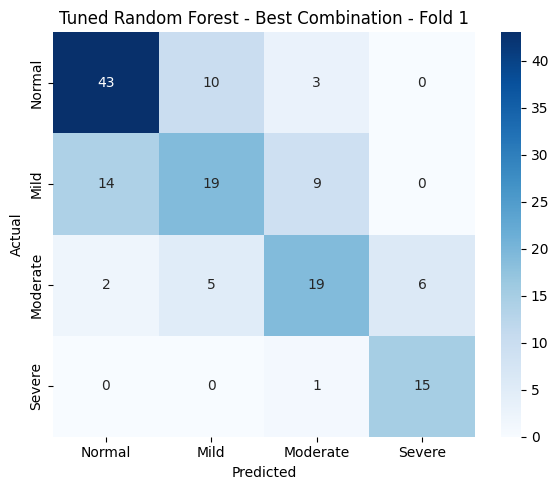

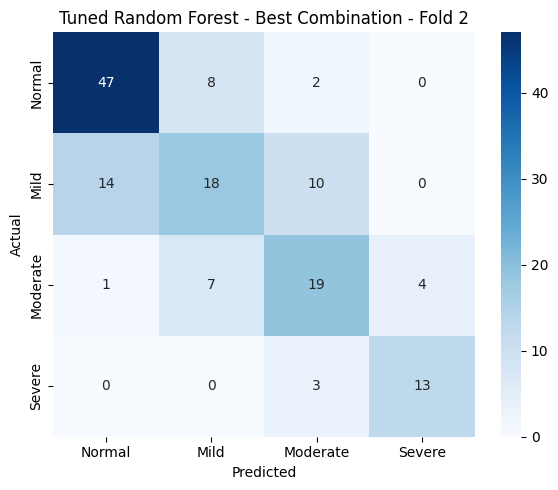

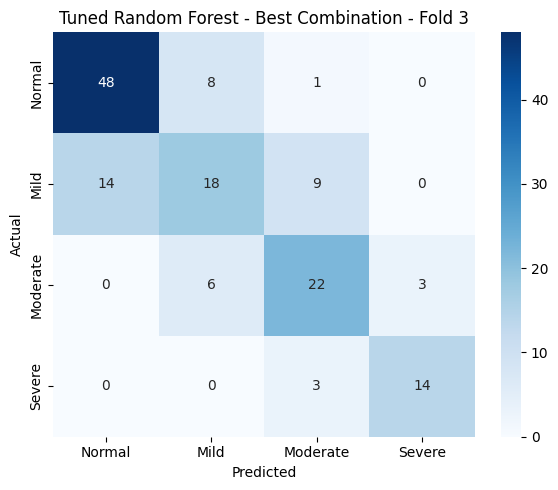

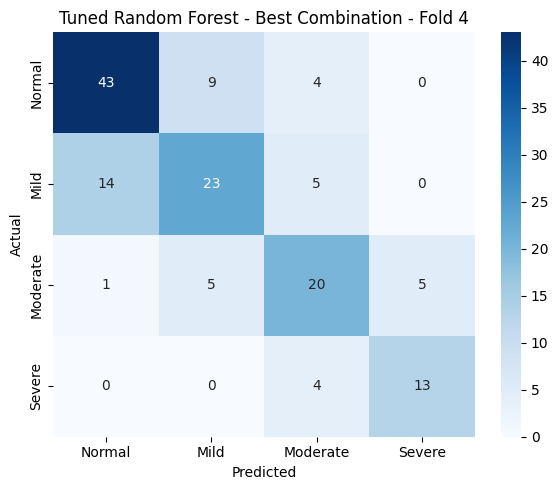

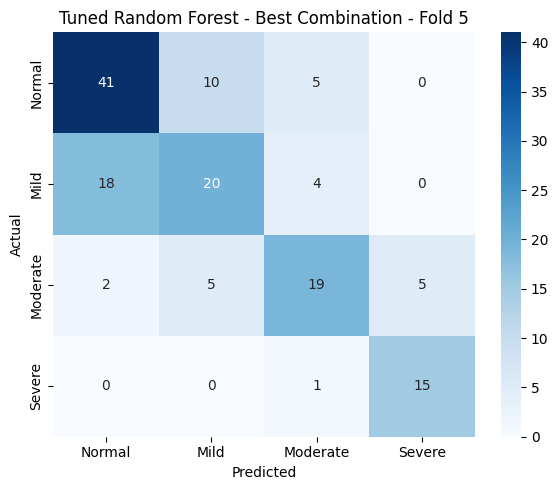


Aggregated Metrics Across All Folds
----------------------------------------------------------------------------------------------------


,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,0.6708,0.6671,0.6861,0.6742,0.5379,0.8162



Aggregated Classification Report Across All Folds
----------------------------------------------------------------------------------------------------


,precision,recall,f1-score,support
Normal,0.7351,0.7872,0.7603,282.0000
Mild,0.5731,0.4689,0.5158,209.0000
Moderate,0.6074,0.6346,0.6207,156.0000
Severe,0.7527,0.8537,0.8000,82.0000
accuracy,0.6708,0.6708,0.6708,0.6708
macro avg,0.6671,0.6861,0.6742,729.0000
weighted avg,0.6633,0.6708,0.6648,729.0000



Aggregated Confusion Matrix


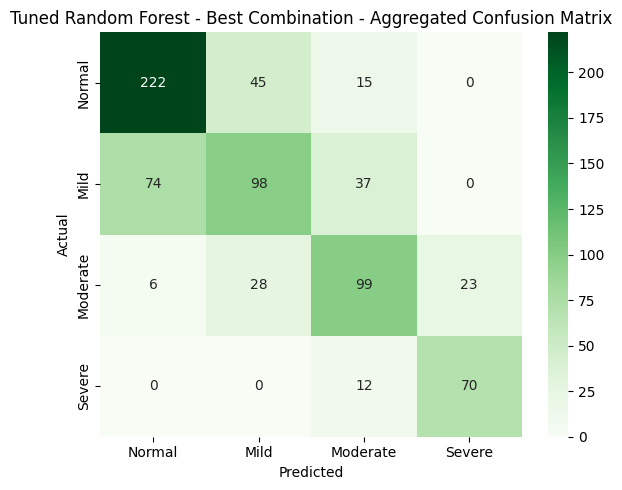

In [52]:
tuned_results, tuned_reports, tuned_aggregated_metrics, tuned_aggregated_report, tuned_cm = run_rf_stratified_cv(
    X=X_train_selected,
    y=y_train,
    experiment_name='Tuned Random Forest - Best Combination',
    model_params=best_model_params
)



In [53]:
comparison_df = pd.concat(
    [
        selected_feature_agg_metrics.rename(index={0: 'Baseline - Selected'}),
        tuned_aggregated_metrics.rename(index={0: 'Tuned - Selected'})
    ],
    axis=0
)

comparison_df

,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
Baseline - Selected,0.6475,0.6466,0.6341,0.6383,0.4997,0.7939
Tuned - Selected,0.6708,0.6671,0.6861,0.6742,0.5379,0.8162


# Final Random Forest Model

In [54]:
X_train_final = X_train[selected_features].copy()
X_test_final = X_test[selected_features].copy()

X_train_final.columns = X_train_final.columns.str.replace(' ', '_')
X_test_final.columns = X_test_final.columns.str.replace(' ', '_')


print("Final training shape :", X_train_final.shape)
print("Final testing shape  :", X_test_final.shape)
print("Selected features    :", list(X_train_final.columns))

final_rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    **best_model_params
)

final_rf_model.fit(X_train_final, y_train)

print("Final tuned Random Forest model has been trained on the full training set.")

Final training shape : (729, 3)
Final testing shape  : (183, 3)
Selected features    : ['MUAP_Amplitude_uV', 'MUAP_Ration_ms', 'MUAP_Polyphasia_Percent']
Final tuned Random Forest model has been trained on the full training set.


# Test Set Evaluation

Final Random Forest - Test Set Metrics


,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,0.6721,0.6669,0.6817,0.6737,0.5398,0.7594


Final Random Forest - Test Classification Report


,precision,recall,f1-score,support
Normal,0.7391,0.7183,0.7286,71.0000
Mild,0.5882,0.5660,0.5769,53.0000
Moderate,0.6585,0.6923,0.6750,39.0000
Severe,0.6818,0.7500,0.7143,20.0000
accuracy,0.6721,0.6721,0.6721,0.6721
macro avg,0.6669,0.6817,0.6737,183.0000
weighted avg,0.6720,0.6721,0.6717,183.0000


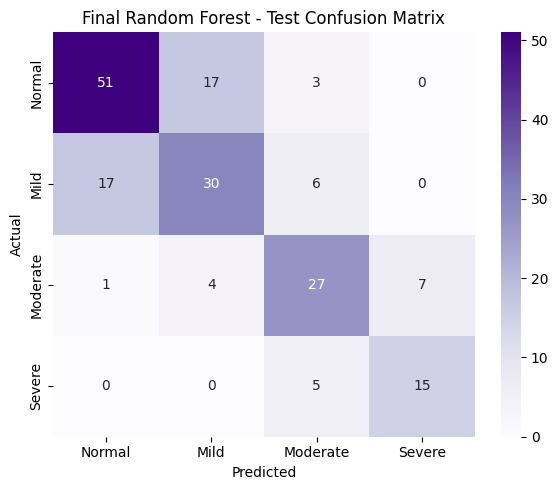

In [55]:
class_names = ['Normal', 'Mild', 'Moderate', 'Severe']
class_labels = [0, 1, 2, 3]

severe_label = 3
severe_index = class_labels.index(severe_label)

y_test_pred = final_rf_model.predict(X_test_final)
y_test_proba = final_rf_model.predict_proba(X_test_final)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision_macro = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
test_recall_macro = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
test_f1_macro = f1_score(y_test, y_test_pred, average='macro', zero_division=0)
test_mcc = matthews_corrcoef(y_test, y_test_pred)

y_test_severe = (y_test == severe_label).astype(int)
y_test_proba_severe = y_test_proba[:, severe_index]
test_ap_severe = average_precision_score(y_test_severe, y_test_proba_severe)

test_metrics_df = pd.DataFrame([{
    'Accuracy': round(test_accuracy, 4),
    'Precision_macro': round(test_precision_macro, 4),
    'Recall_macro': round(test_recall_macro, 4),
    'F1_macro': round(test_f1_macro, 4),
    'MCC': round(test_mcc, 4),
    'AP_Severe': round(test_ap_severe, 4)
}])

print("Final Random Forest - Test Set Metrics")
display(test_metrics_df)

test_report_dict = classification_report(
    y_test,
    y_test_pred,
    labels=class_labels,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

test_report_df = pd.DataFrame(test_report_dict).transpose().round(4)

print("Final Random Forest - Test Classification Report")
display(test_report_df.loc[class_names + ['accuracy', 'macro avg', 'weighted avg']])

test_cm = confusion_matrix(y_test, y_test_pred, labels=class_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Final Random Forest - Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

#Explainable AI

In [56]:
import shap

In [57]:
explainer = shap.TreeExplainer(final_rf_model)

In [58]:
shap_values = explainer.shap_values(X_test_final)


SHAP Summary Plot for: Normal


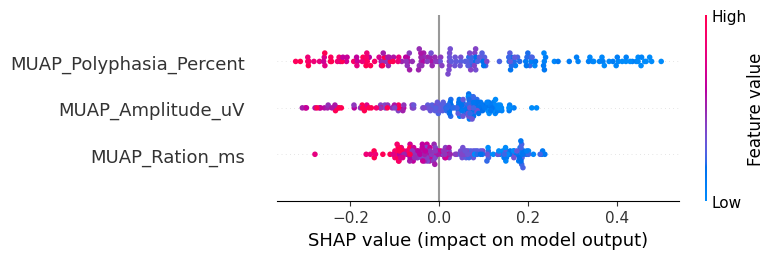


SHAP Summary Plot for: Mild


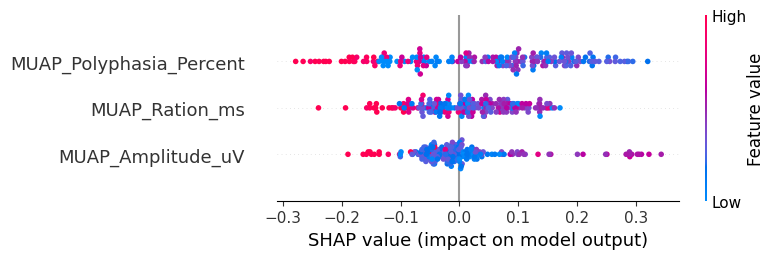


SHAP Summary Plot for: Moderate


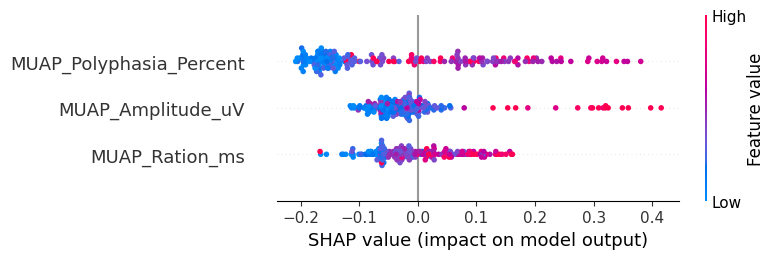


SHAP Summary Plot for: Severe


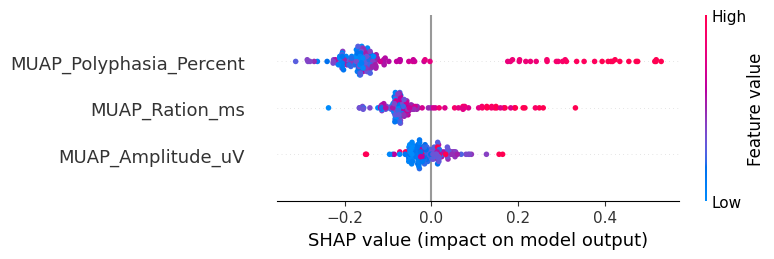

In [63]:
class_names = ["Normal", "Mild", "Moderate", "Severe"]

for i, class_name in enumerate(class_names):
    print(f"\nSHAP Summary Plot for: {class_name}")

    shap.summary_plot(
        shap_values[:, :, i],
        X_test_final,
        feature_names=X_test_final.columns
    )

In [65]:
shap_values_array = np.array(shap_values)



importance_all = []

for i, class_name in enumerate(class_names):
    importance = np.mean(np.abs(shap_values_array[:, :, i]), axis=0)
    importance_all.append(importance)

rf_importance_df = pd.DataFrame(
    np.array(importance_all).T,
    index=X_test_final.columns,
    columns=class_names
)

rf_importance_df

,Normal,Mild,Moderate,Severe
MUAP_Amplitude_uV,0.096816,0.063657,0.062333,0.034170
MUAP_Ration_ms,0.090195,0.066983,0.058566,0.087443
MUAP_Polyphasia_Percent,0.175038,0.126852,0.138174,0.192913


# Overfitting Check

In [66]:
best_cv_accuracy = tuned_aggregated_metrics.loc[0, 'Accuracy']
best_cv_precision_macro = tuned_aggregated_metrics.loc[0, 'Precision_macro']
best_cv_recall_macro = tuned_aggregated_metrics.loc[0, 'Recall_macro']
best_cv_f1_macro = tuned_aggregated_metrics.loc[0, 'F1_macro']
best_cv_mcc = tuned_aggregated_metrics.loc[0, 'MCC']
best_cv_ap_severe = tuned_aggregated_metrics.loc[0, 'AP_Severe']

cv_vs_test_df = pd.DataFrame([
    ['Train Set', best_cv_accuracy, best_cv_precision_macro, best_cv_recall_macro, best_cv_f1_macro, best_cv_mcc, best_cv_ap_severe],
    ['Test Set',  test_accuracy,    test_precision_macro,    test_recall_macro,    test_f1_macro,    test_mcc,    test_ap_severe]
], columns=['Dataset', 'Accuracy', 'Precision_macro', 'Recall_macro', 'F1_macro', 'MCC', 'AP_Severe'])

cv_vs_test_df.iloc[:, 1:] = cv_vs_test_df.iloc[:, 1:].round(4)

print("Train Set vs Test Set")
display(cv_vs_test_df)




Train Set vs Test Set


,Dataset,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,Train Set,0.6708,0.6671,0.6861,0.6742,0.5379,0.8162
1,Test Set,0.6721,0.6669,0.6817,0.6737,0.5398,0.7594


In [67]:
cv_test_gap_df = pd.DataFrame([{
    'Accuracy_Gap': round(best_cv_accuracy - test_accuracy, 4),
    'Precision_macro_Gap': round(best_cv_precision_macro - test_precision_macro, 4),
    'Recall_macro_Gap': round(best_cv_recall_macro - test_recall_macro, 4),
    'F1_macro_Gap': round(best_cv_f1_macro - test_f1_macro, 4),
    'MCC_Gap': round(best_cv_mcc - test_mcc, 4),
    'AP_Severe_Gap': round(best_cv_ap_severe - test_ap_severe, 4)
}])

print("Overfitting Check (Train - Test)")
display(cv_test_gap_df)

Overfitting Check (Train - Test)


,Accuracy_Gap,Precision_macro_Gap,Recall_macro_Gap,F1_macro_Gap,MCC_Gap,AP_Severe_Gap
0,-0.0013,0.0002,0.0044,0.0005,-0.0019,0.0568


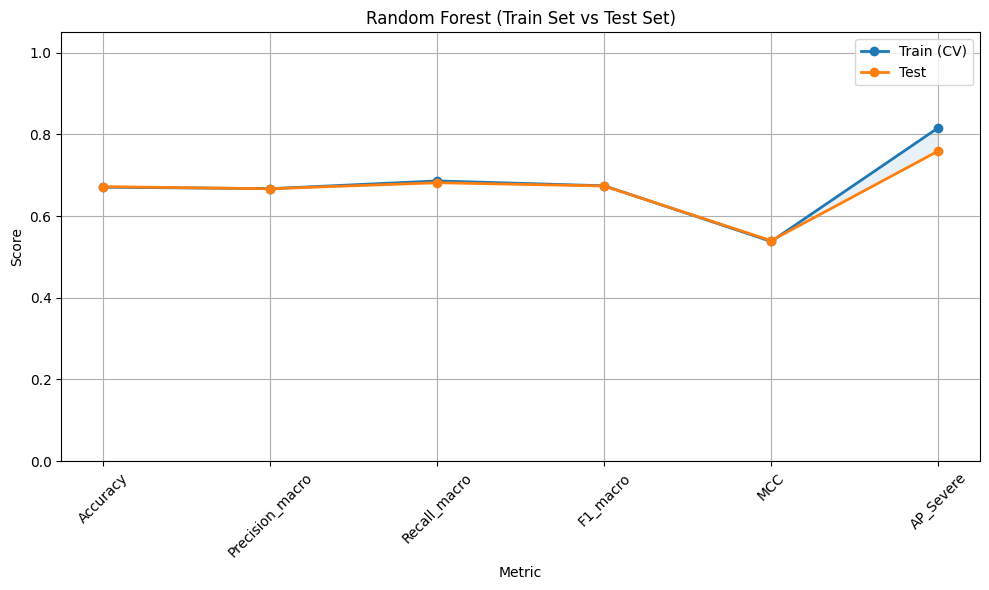

In [68]:

plot_df = cv_vs_test_df.set_index('Dataset').T

plt.figure(figsize=(10, 6))
plt.plot(plot_df.index, plot_df['Train Set'], marker='o', linewidth=2, label='Train (CV)')
plt.plot(plot_df.index, plot_df['Test Set'], marker='o', linewidth=2, label='Test')
plt.fill_between(plot_df.index, plot_df['Train Set'], plot_df['Test Set'], alpha=0.1)
plt.title("Random Forest (Train Set vs Test Set)")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.xticks(rotation=45)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Sample Predictions

In [69]:
label_names = {
    0: 'Normal',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe'
}

sample_predictions_named = pd.DataFrame({
    'Actual': y_test.map(label_names).values,
    'Predicted': pd.Series(y_test_pred, index=y_test.index).map(label_names).values
}, index=y_test.index)

print("Sample Predictions with Class Names")
display(sample_predictions_named.head(10))

proba_df = pd.DataFrame(
    y_test_proba,
    columns=['Prob_Normal', 'Prob_Mild', 'Prob_Moderate', 'Prob_Severe'],
    index=y_test.index
)

prediction_with_proba = pd.concat([sample_predictions_named, proba_df], axis=1)

print("Sample Predictions with Probabilities")
display(prediction_with_proba.head(10))

errors_df = prediction_with_proba[
    prediction_with_proba['Actual'] != prediction_with_proba['Predicted']
]

print("Misclassified Samples")
display(errors_df.head(10))

Sample Predictions with Class Names


,Actual,Predicted
515,Moderate,Severe
872,Normal,Normal
224,Normal,Mild
648,Severe,Severe
862,Mild,Mild
486,Normal,Normal
208,Mild,Normal
830,Normal,Mild
630,Normal,Normal
530,Severe,Moderate


Sample Predictions with Probabilities


,Actual,Predicted,Prob_Normal,Prob_Mild,Prob_Moderate,Prob_Severe
515,Moderate,Severe,0.025445,0.017067,0.226553,0.730936
872,Normal,Normal,0.615575,0.333719,0.043815,0.006891
224,Normal,Mild,0.432652,0.522449,0.019056,0.025843
648,Severe,Severe,0.001520,0.003383,0.139424,0.855673
862,Mild,Mild,0.163709,0.658988,0.163959,0.013344
486,Normal,Normal,0.623380,0.335716,0.039288,0.001616
208,Mild,Normal,0.825083,0.143963,0.017973,0.012980
830,Normal,Mild,0.078998,0.499182,0.401317,0.020504
630,Normal,Normal,0.494772,0.366564,0.131817,0.006847
530,Severe,Moderate,0.154907,0.149041,0.610928,0.085124


Misclassified Samples


,Actual,Predicted,Prob_Normal,Prob_Mild,Prob_Moderate,Prob_Severe
515,Moderate,Severe,0.025445,0.017067,0.226553,0.730936
224,Normal,Mild,0.432652,0.522449,0.019056,0.025843
208,Mild,Normal,0.825083,0.143963,0.017973,0.012980
830,Normal,Mild,0.078998,0.499182,0.401317,0.020504
530,Severe,Moderate,0.154907,0.149041,0.610928,0.085124
322,Moderate,Severe,0.052238,0.042785,0.367492,0.537484
324,Mild,Normal,0.573051,0.417629,0.008331,0.000989
760,Moderate,Mild,0.220515,0.482004,0.291649,0.005832
372,Mild,Moderate,0.063289,0.290561,0.437149,0.209001
624,Mild,Normal,0.459953,0.311185,0.217893,0.010969


# Train on Full Dataset + Save Deployment Model

In [70]:
X_full_selected = pd.concat([
    X_train[selected_features],
    X_test[selected_features]
], axis=0)

y_full = pd.concat([y_train, y_test], axis=0)

X_full_selected = X_full_selected.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

print("Full dataset shape :", X_full_selected.shape)
print("Full target shape  :", y_full.shape)
print("Selected features  :", selected_features)

X_full_selected.columns = X_full_selected.columns.str.replace(' ', '_')

print("Final feature names :", list(X_full_selected.columns))

final_deployment_rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    **best_model_params
)

final_deployment_rf_model.fit(X_full_selected, y_full)

print("Final deployment Random Forest model has been trained on the full dataset.")

deployment_bundle = {
    'model': final_deployment_rf_model,
    'selected_features': selected_features,
    'label_names': {
        0: 'Normal',
        1: 'Mild',
        2: 'Moderate',
        3: 'Severe'
    }
}

joblib.dump(deployment_bundle, 'final_rf_deployment_bundle.pkl')

print("Deployment bundle saved successfully.")

Full dataset shape : (912, 3)
Full target shape  : (912,)
Selected features  : ['MUAP Amplitude uV', 'MUAP Ration ms', 'MUAP Polyphasia Percent']
Final feature names : ['MUAP_Amplitude_uV', 'MUAP_Ration_ms', 'MUAP_Polyphasia_Percent']
Final deployment Random Forest model has been trained on the full dataset.
Deployment bundle saved successfully.


# Load Bundle + New Sample Prediction

In [71]:
deployment_bundle = joblib.load('final_rf_deployment_bundle.pkl')

loaded_model = deployment_bundle['model']
loaded_selected_features = deployment_bundle['selected_features']
loaded_label_names = deployment_bundle['label_names']

print("Bundle loaded successfully.")

Bundle loaded successfully.


In [72]:
new_sample = pd.DataFrame([{
    'MUAP Polyphasia Percent': 35,
    'MUAP Ration ms': 12,
    'MUAP Amplitude uV': 450
}])

new_sample = new_sample[loaded_selected_features].copy()
new_sample.columns = new_sample.columns.str.replace(' ', '_')

new_prediction = loaded_model.predict(new_sample)[0]
new_prediction_proba = loaded_model.predict_proba(new_sample)[0]

print("EMG Input Values:")
for col, val in new_sample.iloc[0].items():
    print(f"{col}: {val}")

print("\nPredicted Strength Severity:")
print(f"{loaded_label_names[new_prediction]}")

print("\nConfidence Scores Across Classes:")
for i, prob in enumerate(new_prediction_proba):
    class_name = loaded_label_names[i]
    print(f"{class_name:<9}: {prob*100:.1f}%")

EMG Input Values:
MUAP_Amplitude_uV: 450
MUAP_Ration_ms: 12
MUAP_Polyphasia_Percent: 35

Predicted Strength Severity:
Moderate

Confidence Scores Across Classes:
Normal   : 10.8%
Mild     : 27.2%
Moderate : 48.8%
Severe   : 13.2%
